# Pretreatment Temperature Extraction

## Packages, Variables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import PureWindowsPath

import os
import warnings
import re
from pathlib import Path
from datetime import datetime

In [2]:
import platform
from matplotlib import rcParams

system = platform.system()

# OSごとにmatplotlibで使用するフォントを指定（システムになければフォントを追加する）
if system == "Windows":
    rcParams["font.family"] = "Meiryo"
elif system == "Darwin":  # macOS
    rcParams["font.family"] = "Hiragino Sans"
else:  # Linux
    rcParams["font.family"] = "IPAexGothic"

rcParams["font.size"] = 12

In [3]:
# data directory
DATA_DIRECTORY = "Data/dummy_data/"

# このノート由来の生成ファイルであることが分かるようにする出力先ルートフォルダ
OUTPUT_ROOT = "PretreatmentTemp"

# save summary as csv or noct
IS_SAVESUMMARY = True
CSV_DIRECTORY = os.path.join(OUTPUT_ROOT, "summary_table/")

# save summary as pickle or noct
IS_SAVEPICKLE = True

# save graph as png or noct
IS_SAVEGRAPH = True
GRAPH_DIRECTORY = os.path.join(OUTPUT_ROOT, "Graph/")

# get_datainfo_and_temperatureinfo()がintegrated_dataを初期化する際のキー（列）の並び順
COLUMN_ORDER = ['trend_filepath', 'trend_filename', 'measurement_method', 'pretreatment_date', 'sample_filepath',
                '測定者', '装置', 'ファイルパス', 'サンプル名', 'サンプル種類', 'サンプル重量',
                '前処理ガス', '前処理流量', '前処理時間', '前処理温度', '設定値24', '設定値25',
                '設定値28', '設定値29', '設定値31', 'パルス数',
                '測定値A8合計', '測定値A8合計 / サンプル重量', '測定値A8合計（15回まで）', '測定値A8合計（15回まで） / サンプル重量',
                '測定値A8合計（15回まで） / 測定値A8合計',
                '測定部温度', 'ヒーター温度', 'ヒーター温度 - 測定部温度']

# get_datainfo_and_temperatureinfo()が返すDataFrameの列名を英語に変換するマッピング
COLUMN_NAME_MAP = {
    '測定者': 'operator',
    '装置': 'machine',
    'ファイルパス': 'internal_filepath',  # 分析装置側に記録された内部パス（trend_filepathキーとは別物）
    'サンプル名': 'sample_name',
    'サンプル種類': 'sample_type',
    'サンプル重量': 'sample_weight',
    '前処理ガス': 'pretreatment_gas',
    '前処理流量': 'pretreatment_flowrate',
    '前処理時間': 'pretreatment_time',
    '前処理温度': 'pretreatment_temperature',
    '設定値24': 'setting_value_24',
    '設定値25': 'setting_value_25',
    '設定値28': 'setting_value_28',
    '設定値29': 'setting_value_29',
    '設定値31': 'setting_value_31',
    'パルス数': 'pulse_count',
    '測定値A8合計': 'measured_value_a8_total',
    '測定値A8合計（15回まで）': 'measured_value_a8_total_0to15',
    '測定値A8合計（15回まで） / 測定値A8合計': 'measured_value_a8_total_0to15_ratio',
    '測定値A8合計 / サンプル重量': 'measured_value_a8_total_per_weight',
    '測定値A8合計（15回まで） / サンプル重量': 'measured_value_a8_total_0to15_per_weight',
    '測定部温度': 'measured_temp',
    'ヒーター温度': 'heater_temp',
    'ヒーター温度 - 測定部温度': 'heater_measured_diff',
}

# machine/measurement_method/periodなど、ノート全体で繰り返し使うカテゴリの色をここで固定する。
# huecolumnに何が渡されても実際に存在する値だけが参照されるため、全プロット呼び出しに
# そのまま使い回せる
CATEGORY_COLOR_MAP = {
    'MachineA': 'tab:orange',
    'MachineB': 'tab:green',
    'MethodA': 'tab:pink',
    'MethodB': 'tab:gray',
    'Before 2025-01-01': 'tab:cyan',
    'After 2025-01-01': 'tab:red',
}

# カテゴリ分け（hue）をしないプロットのデフォルト色
DEFAULT_COLOR = 'tab:blue'

## Methods

### Get files

In [4]:
import os
import shutil

def get_all_csv_files(directory):
    """
    指定されたディレクトリとそのすべてのサブディレクトリから
    CSVファイルのパスをリストとして取得する関数
    
    Args:
        directory (str): 検索を開始するディレクトリのパス
        
    Returns:
        list: 見つかったすべてのCSVファイルの絶対パスのリスト
    """
    csv_files = []
    
    # os.walkを使用して再帰的にディレクトリを探索
    for root, dirs, files in os.walk(directory):
        for file in files:
            # 拡張子が.csvのファイルだけをリストに追加
            if file.lower().endswith('.csv'):
                # ファイルの絶対パスを作成して追加
                csv_files.append(os.path.join(root, file))
    
    return csv_files

def get_trend_csv_files(directory):
    """
    指定されたディレクトリとそのすべてのサブディレクトリから
    CSVファイルのパスをリストとして取得し、特定のプレフィックスを持つファイルを除外する関数
    
    Args:
        directory (str): 検索を開始するディレクトリのパス
        exclude_prefix (str): 除外するファイル名のプレフィックス（デフォルトは"Trend"）
        
    Returns:
        list: フィルタリングされたCSVファイルの絶対パスのリスト
    """
    csv_files = []
    
    # os.walkを使用して再帰的にディレクトリを探索
    for root, dirs, files in os.walk(directory):
        for file in files:
            # basenameを取得（ファイル名のみ）
            basename = os.path.basename(file)

            # 拡張子が.csvで、ファイル名に"Trend"から始まるファイルだけをリストに追加
            if file.lower().endswith('.csv') and basename.startswith('Trend'):
                # ファイルの絶対パスを作成して追加
                csv_files.append(os.path.join(root, file))
    
    return csv_files

### Methods from "extract_conditions.ipynb"

In [5]:
# 特定の列で最初のNaNが出現するまでの行を抽出する関数
def extract_until_first_nan(df, column='STEP'):
    # NaNが最初に出現するインデックスを見つける
    first_nan_idx = df[df[column].isna()].index.min()
    
    if pd.isna(first_nan_idx):
        # NaNが見つからない場合は全ての行を返す
        return df
    else:
        # 最初のNaNが出現する前までの行を返す
        return df.loc[:first_nan_idx-1]

In [6]:
def check_file_validity(file_path):
    """
    ファイルの有効性をチェックする関数

    Parameters:
    -----------
    file_path : str
        チェックするファイルのパス

    Returns:
    --------
    bool
        ファイルが有効な場合はTrue、そうでない場合はFalse
    str or None
        エラーメッセージ（エラーがある場合）、なければNone
    """
    if not os.path.exists(file_path):
        return False, f"ファイル '{file_path}' は存在しません。"

    if os.path.isdir(file_path):
        return False, f"'{file_path}' はディレクトリです。CSVファイルのパスを指定してください。"

    if not file_path.lower().endswith('.csv'):
        return False, f"'{file_path}' はCSVファイルではありません。"

    if not os.access(file_path, os.R_OK):
        return False, f"'{file_path}' には読み取り権限がありません。"

    return True, None

In [7]:
def get_h2chemfile_list(dirpath: str = 'Data'):
    files = os.listdir(dirpath)
    h2chemfiles = [f'{dirpath}/{file}' for file in files if not file.startswith('Trend')]

    return h2chemfiles


def _dataframe_section(raw_df, headnum, usecols):
    """
    raw_df（get_header_positions等と同じくnames=range(0, 16)で読み込んだ生データ）から、
    pd.read_csv(file, header=headnum, usecols=usecols)相当の部分DataFrameを、
    ディスクを再度読まずに切り出す。
    """
    sub = raw_df.iloc[headnum:, list(usecols)].reset_index(drop=True)
    new_columns = sub.iloc[0]
    sub = sub.iloc[1:].reset_index(drop=True)
    sub.columns = new_columns
    return sub


def get_header_positions(file: str = None, raw_df=None):
    """取得したいデータが記載されている箇所のヘッダー位置を取得"""
    if raw_df is None:
        raw_df = pd.read_csv(file, names=range(0, 16), encoding='shift_jis')

    labels = ['保存ファイル名', '前処理開始日時', 'STEP', '設定値0', '測定開始日時', '測定値A1', '測定結果8']
    row_numbers = {key: None for key in labels}

    # 列1をラベルの集合で1回だけ絞り込み、ラベルごとの最初の出現行をまとめて求める
    # （ラベルごとに個別にraw_df[1] == keyを7回走査するのを1回にまとめる）
    matches = raw_df[raw_df[1].isin(labels)]
    first_occurrences = matches.drop_duplicates(subset=1, keep='first')
    row_numbers.update({label: int(idx) for label, idx in zip(first_occurrences[1], first_occurrences.index)})

    return row_numbers


# サンプル種類の判定に使う候補文字列（ファイル名にいずれかが含まれていれば該当種類とする）
SAMPLE_TYPES = ['SampleA', 'SampleB', 'SampleC', 'SampleD', 'SampleE', 'SampleF']


def load_and_extract_sampleinfo(file: str, headnum: int | None = None, raw_df=None):
    """装置、サンプル名などの情報を取得"""
    # Noneの場合、デフォルト値14を使用
    if headnum is None:
        headnum = 14

    basefilename = os.path.basename(file)

    # Initialize all return variables
    name = np.nan
    which_machine = np.nan
    datafilepath = np.nan
    sample_name = np.nan
    sample_weight = np.nan
    sample_type = 'others'

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 3))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 3), encoding='shift_jis')

        # filter continuous dataframe from top
        df = extract_until_first_nan(df, "保存ファイル名")

        # Extract filepath (do this first as other operations depend on it)
        try:
            datafilepath = df.columns[1]
        except Exception:
            datafilepath = np.nan

        # Extract who's folder
        try:
            if isinstance(datafilepath, str):
                path = PureWindowsPath(datafilepath)
                name = path.parts[3] if len(path.parts) > 3 else np.nan
        except Exception:
            name = np.nan

        # Which machine was used (MachineA or MachineB)
        try:
            if isinstance(datafilepath, str):
                path = PureWindowsPath(datafilepath)
                which_machine = path.parts[1] if len(path.parts) > 1 else np.nan
        except Exception:
            which_machine = np.nan

        # Extract sample name
        try:
            sample_name_rows = df[df['保存ファイル名'] == 'サンプル名']
            sample_name = sample_name_rows.iloc[0, 1] if not sample_name_rows.empty else np.nan
        except Exception:
            sample_name = np.nan

        # Extract sample weight
        try:
            sample_weight_rows = df[df['保存ファイル名'] == 'サンプル重量']
            sample_weight = float('0' + sample_weight_rows.iloc[0, 1]) if not sample_weight_rows.empty else np.nan
        except Exception:
            sample_weight = np.nan

        # Determine sample type（候補文字列のいずれかがファイル名に含まれていれば該当種類とする）
        try:
            file_lower = basefilename.lower()
            for candidate in SAMPLE_TYPES:
                if candidate.lower() in file_lower:
                    sample_type = candidate
                    break
        except Exception:
            sample_type = 'others'

    except Exception as e:
        # If the CSV file can't be read at all, all values will remain as initialized
        print(f"Error => {str(e)}")
        pass

    return {
        '測定者': name,
        '装置': which_machine,
        'ファイルパス': datafilepath,
        'サンプル名': sample_name,
        'サンプル種類': sample_type,
        'サンプル重量': sample_weight
    }

def load_and_extract_date(file: str = None, headnum: int | None = None, raw_df=None):
    # Noneの場合、デフォルト値24を使用
    if headnum is None:
        headnum = 24

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 3))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 3), encoding='shift_jis')
        date = df.columns[1].replace('#', '')
        parsed_date = pd.to_datetime(date).normalize()  # 時刻情報は使わないため00:00に正規化
    except Exception:
        parsed_date = np.nan

    return {'pretreatment_date': parsed_date}

def df_pretreatment_sequence(file: str = None, headnum: int | None = None, raw_df=None):
    """前処理シークエンスのデータを取得"""
    # Noneの場合、デフォルト値27を使用
    if headnum is None:
        headnum = 27
    cols = ['STEP', 'ガス', '流量', '時間', '温度', 'X機構']

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 7))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 7), encoding='shift_jis')
        df.columns = cols

        # get continuous dataframe from top
        df = extract_until_first_nan(df, "STEP")

        # change data types
        df['STEP'] = df['STEP'].astype(int)
        for row in ['流量', '時間', '温度']:
            df[row] = df[row].astype(float)
    except Exception:
        # 例外が発生した場合は、空のDataFrameを返す
        df = pd.DataFrame(columns=cols)

    return df

def extract_pretreatment_conditions(df, step: int = 3):
    """前処理シークエンスから指定したSTEPの条件を取得"""
    conditions = {
        '前処理ガス': np.nan,
        '前処理流量': np.nan,
        '前処理時間': np.nan,
        '前処理温度': np.nan,
    }

    try:
        for row in ['ガス', '流量', '時間', '温度']:
            value = df[df['STEP'] == step][row].iloc[0]
            conditions[f'前処理{row}'] = value
    except Exception:
        # 例外が発生した場合は、すでにnp.nanで初期化されているのでそのまま返す
        pass

    return conditions


def load_and_extract_pulse_condition(file: str = None, headnum: int | None = None, raw_df=None):
    """パルス測定のパージ・導入・パルス回数などの設定値を取得"""
    # Noneの場合、デフォルト値37を使用
    if headnum is None:
        headnum = 37

    # キー: 返り値の名前、値: 検索するラベル文字列
    labels = {
        '設定値24': '設定値24',
        '設定値25': '設定値25',
        '設定値28': '設定値28',
        '設定値29': '設定値29',
        '設定値31': '設定値31',
        'パルス数': 'パルス数',
    }
    result = {key: np.nan for key in labels}

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 3))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 3), encoding='shift_jis')

        # 各項目について、該当する行が存在する場合のみ値を取得
        for key, label in labels.items():
            target_row = df[df['設定値0'] == label]
            if not target_row.empty:
                result[key] = int(target_row.iloc[0, 1])
    except Exception:
        # 例外が発生した場合は、すでにnp.nanで初期化されているのでそのまま返す
        pass

    return result

def load_and_extract_measured_value_a8(file: str = None, sample_weight: float = np.nan, headnum: int | None = None, lastrownum: int | None = 130, raw_df=None):
    """測定値A8合計などの測定結果を取得"""
    # Noneの場合、デフォルト値80を使用
    if headnum is None:
        headnum = 80
    if lastrownum is None:
        lastrownum = 130

    result = {
        '測定値A8合計': np.nan,
        '測定値A8合計 / サンプル重量': np.nan,
        '測定値A8合計（15回まで）': np.nan,
        '測定値A8合計（15回まで） / サンプル重量': np.nan,
        '測定値A8合計（15回まで） / 測定値A8合計': np.nan,

    }

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 15))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 15), encoding='shift_jis')
        # ヘッダー以降、次のセクションが始まる手前まで（lastrownum）に読む範囲を絞る
        df = df.head(lastrownum - headnum)
        df = extract_until_first_nan(df, '測定値A1')

        # 測定値A8の合計が記載されている行
        total_rows = df[df['測定値A1'] == '測定結果3']

        if not total_rows.empty and '測定値A2' in total_rows.columns:
            # 測定値A2列に測定値A8の合計値が記録されている
            total_measured_value_a8 = float('0' + total_rows['測定値A2'].iloc[0])

            # enter values to result dictionary
            result['測定値A8合計'] = total_measured_value_a8
            result['測定値A8合計 / サンプル重量'] = round(total_measured_value_a8 / sample_weight, 4)

            if '測定値A8' in df.columns:
                measured_value_a8_0to15 = float(df['測定値A8'][0:16].astype(float).sum())

                # enter values to result dictionary
                result['測定値A8合計（15回まで）'] = round(measured_value_a8_0to15, 4)
                result['測定値A8合計（15回まで） / サンプル重量'] = round(measured_value_a8_0to15 / sample_weight, 4)

                if total_measured_value_a8 != 0:
                    result['測定値A8合計（15回まで） / 測定値A8合計'] = round(measured_value_a8_0to15 / total_measured_value_a8, 4)
    except Exception:
        # 例外が発生した場合は、すでにnp.nanで初期化されているのでそのまま返す
        pass

    return result


In [8]:
def parse_trend_filename_and_match_sample(filepath):
    """
    Process file information based on the given filepath.

    Args:
        filepath (str): Path to the file (e.g., 'Data/Taro/Trend_sampleA_240101-MethodA-240530-0924.csv')

    Returns:
        dict: Dictionary containing trend_filepath, trend_filename, measurement_method, trend_filename_datetime, and sample_filepath
    """
    # Normalize the input filepath to use consistent separators (絶対パス化はしない)
    filepath = os.path.normpath(filepath)

    # Determine which separator style to use based on input filepath
    separator = '/' if '/' in filepath else '\\'

    # Get the basename of the filepath
    filename = os.path.basename(filepath)

    # datatypeはTrendファイル自身のファイル名から判定する（'MethodA-'/'MethodB-'を含むかどうか）
    if 'MethodA-' in filename:
        datatype = 'MethodA'
    elif 'MethodB-' in filename:
        datatype = 'MethodB'
    else:
        datatype = np.nan

    # Extract datetime part from the filename
    match = re.search(r'-(\d+-\d+)', filename)
    if not match or pd.isna(datatype):
        return {
            "trend_filepath": filepath.replace('\\', separator).replace('/', separator),
            "trend_filename": filename,
            "measurement_method": datatype,
            "trend_filename_datetime": None,
            "sample_filepath": None
        }

    datetime_part = match.group(1)

    # Convert datetime_part to datetime object
    try:
        # Parse the datetime part (format: YYMMDD-HHMM)
        date_obj = datetime.strptime(datetime_part, '%y%m%d-%H%M')
    except ValueError:
        date_obj = None

    # sampleから始まるデータファイルはTrendファイルと同じディレクトリ内に生成されるため、
    # 探索範囲をTrendファイルと同じディレクトリに限定する
    dirpath = os.path.dirname(filepath)

    matched_filepath = None
    try:
        for file in os.listdir(dirpath):
            # Skip files that start with 'Trend' or contain "edited" in file name
            if file.startswith('Trend') or 'edited' in file:
                continue

            # Trendファイル自身のdatatypeと同じ'{datatype}-{datetime_part}'を含むファイルを探す
            if f'{datatype}-{datetime_part}' in file:
                potential_match = Path(dirpath) / file
                if potential_match.exists():
                    matched_filepath = str(potential_match)
                    break
    except Exception as e:
        print(f"Error checking file existence: {str(e)}")

    # Normalize paths to use consistent separators
    normalized_filepath = filepath.replace('\\', separator).replace('/', separator)

    if matched_filepath:
        normalized_matched_filepath = str(matched_filepath).replace('\\', separator).replace('/', separator)
    else:
        normalized_matched_filepath = None

    # Return the result as a dictionary
    return {
        "trend_filepath": normalized_filepath,
        "trend_filename": filename,
        "measurement_method": datatype,
        "trend_filename_datetime": date_obj,
        "sample_filepath": normalized_matched_filepath
    }


In [9]:
def dataframe_trend(filename):
    df = pd.read_csv(filename, header=1, usecols=["SEC", "測定部温度", "ヒーター温度"], encoding="shift_jis")
    df['min'] = df['SEC'] / 60
    df['hour'] = df['SEC'] / 3600

    return df

In [10]:
def calculate_constant_temp_average(df, time_col="SEC", temp_col="測定部温度",
                                             temp_threshold=3, min_duration_minutes=10,
                                             min_temp=90):
    """
    Calculate the average temperature of the first constant temperature region
    after a heating phase, with a minimum temperature requirement.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing temperature trend data
    time_col : str, optional
        Name of the time column (default: "SEC")
    temp_col : str, optional
        Name of the temperature column (default: "測定部温度")
    temp_threshold : float, optional
        Maximum temperature variation allowed within 5 minutes to be considered constant (default: 3℃)
    min_duration_minutes : float, optional
        Minimum duration in minutes for a region to be considered a constant temperature zone (default: 10)
    min_temp : float, optional
        Minimum temperature for a region to be considered a valid constant temperature zone (default: 90℃)

    Returns:
    --------
    float
        Average temperature of the first constant temperature region after heating
    """
    import numpy as np
    import pandas as pd
    from collections import deque

    # Ensure the dataframe is sorted by time (skip the copy+sort if already sorted)
    if not df[time_col].is_monotonic_increasing:
        df = df.sort_values(by=time_col).reset_index(drop=True)

    # Convert time to seconds if it's not already
    if df[time_col].dtype == 'timedelta64[ns]' or isinstance(df[time_col].iloc[0], pd.Timestamp):
        time_seconds = (df[time_col] - df[time_col].min()).dt.total_seconds().to_numpy()
    else:
        time_seconds = df[time_col].to_numpy(dtype=float)

    temp_values = df[temp_col].to_numpy(dtype=float)

    # Initialize variables
    window_size_seconds = 5 * 60  # 5 minutes in seconds
    min_duration_seconds = min_duration_minutes * 60

    # window: 直近5分間の(time, temp)を保持し、区間サイズ・開始位置の把握に使う。
    # max_dq/min_dq: モノトニックデック。先頭が常にwindow内の最大値/最小値になるよう維持することで、
    # 「窓内のmax-min」を毎回window全体を見直さずO(1)で求められるようにする。
    window = deque()
    max_dq = deque()
    min_dq = deque()
    region_start_idx = 0
    region_start_time = time_seconds[0]
    in_constant_region = False

    n = len(temp_values)
    for i in range(n):
        current_time = time_seconds[i]
        current_temp = temp_values[i]

        # Skip this point if temperature is below minimum threshold
        if current_temp < min_temp:
            # If we were in a constant region, reset it
            if in_constant_region:
                in_constant_region = False
                window.clear()
                max_dq.clear()
                min_dq.clear()
            continue

        # Remove points older than 5 minutes from the window
        while window and window[0][0] < current_time - window_size_seconds:
            window.popleft()
        while max_dq and max_dq[0][0] < current_time - window_size_seconds:
            max_dq.popleft()
        while min_dq and min_dq[0][0] < current_time - window_size_seconds:
            min_dq.popleft()

        # Add current point to the window
        window.append((current_time, current_temp))

        # モノトニックデックを維持：末尾から見て、新しい値以下（最大値側）／以上（最小値側）の
        # 値はもう先頭になり得ないので捨ててから追加する
        while max_dq and max_dq[-1][1] <= current_temp:
            max_dq.pop()
        max_dq.append((current_time, current_temp))

        while min_dq and min_dq[-1][1] >= current_temp:
            min_dq.pop()
        min_dq.append((current_time, current_temp))

        # Check temperature variation in the current window
        if len(window) > 1:
            temp_variation = max_dq[0][1] - min_dq[0][1]

            if not in_constant_region:
                # If we're not in a constant region and variation is within threshold,
                # we might be entering a constant region
                if temp_variation <= temp_threshold:
                    # Start tracking a potential constant region
                    region_start_idx = i - len(window) + 1
                    region_start_time = window[0][0]
                    in_constant_region = True

            else:  # We're in a potential constant region
                # If variation exceeds threshold, end the current region
                if temp_variation > temp_threshold:
                    in_constant_region = False
                    # Reset tracking
                    window.clear()
                    window.append((current_time, current_temp))
                    max_dq.clear()
                    max_dq.append((current_time, current_temp))
                    min_dq.clear()
                    min_dq.append((current_time, current_temp))
                else:
                    # We're still in a constant region, check if it's long enough
                    region_duration = current_time - region_start_time
                    if region_duration >= min_duration_seconds:
                        # We found our first valid constant region with temperature above min_temp
                        return temp_values[region_start_idx:i + 1].mean()

    # Check if the last region is valid
    if in_constant_region:
        region_duration = time_seconds[-1] - region_start_time
        if region_duration >= min_duration_seconds:
            return temp_values[region_start_idx:].mean()

    # If no constant regions found, return NaN
    return np.nan

In [11]:
def calculate_heater_and_measured_temp(filepath):
    df = dataframe_trend(filepath)
    
    temp_measured = calculate_constant_temp_average(df, time_col="SEC", 
                                           temp_col="測定部温度", temp_threshold=3, min_duration_minutes=10)
    temp_heater = calculate_constant_temp_average(df, time_col="SEC", 
                                           temp_col="ヒーター温度", temp_threshold=3, min_duration_minutes=10)

    temp_diff = temp_heater - temp_measured
    
    return {
        "測定部温度": temp_measured,
        "ヒーター温度": temp_heater,
        "ヒーター温度 - 測定部温度": temp_diff
    }

In [12]:
def get_datainfo_and_temperatureinfo(filepath):
    # リストの要素をキーとし、値がnp.nanの辞書を作成
    integrated_data = {key: np.nan for key in COLUMN_ORDER}
    error_detail = None

    # collect each condition data
    datainfo = parse_trend_filename_and_match_sample(filepath)
    # trend_filename_datetime（Trendファイル名由来の日時）はpretreatment_dateとの突き合わせ確認にのみ使い、最終的な列としては残さない
    trend_filename_datetime = datainfo.pop('trend_filename_datetime', None)
    temperature_info = calculate_heater_and_measured_temp(filepath)

    # integrate each condition data to one dictionary
    integrated_data.update(datainfo)
    integrated_data.update(temperature_info)

    datatype = datainfo['measurement_method']

    if datainfo['sample_filepath'] and ((datatype == 'MethodA') or (datatype == 'MethodB')):
        try:
            # constant temperature step: MethodA => 3, MethodB => 2
            if datatype == 'MethodA':
                stepnum = 3
            elif datatype == 'MethodB':
                stepnum = 2

            matched_file = datainfo['sample_filepath']

            # matched_fileを1回だけ読み込み、以降の抽出処理はディスクを再度読まずに使い回す
            raw_df = pd.read_csv(matched_file, names=range(0, 16), encoding='shift_jis')

            headers = get_header_positions(raw_df=raw_df)

            sample_info = load_and_extract_sampleinfo(matched_file, headers['保存ファイル名'], raw_df=raw_df)
            date = load_and_extract_date(matched_file, headers['前処理開始日時'], raw_df=raw_df)
            pretreatment_condition = extract_pretreatment_conditions(
                df_pretreatment_sequence(matched_file, headers['STEP'], raw_df=raw_df),
                step=stepnum
            )
            purge_condition = load_and_extract_pulse_condition(matched_file, headers['設定値0'], raw_df=raw_df)
            measured_value_a8_info = load_and_extract_measured_value_a8(matched_file, sample_info['サンプル重量'], headers['測定値A1'], headers['測定結果8'], raw_df=raw_df)

            # 念のため、Trendファイル名由来の日付とサンプルファイル内の「前処理開始日時」の日付を突き合わせて確認する
            pretreatment_date = date.get('pretreatment_date')
            if trend_filename_datetime is not None and pd.notna(pretreatment_date):
                if trend_filename_datetime.date() != pretreatment_date.date():
                    error_detail = f"Date mismatch: trend_filename_datetime={trend_filename_datetime}, pretreatment_date={pretreatment_date}"
                    print(f"[Date mismatch] {filepath}: {error_detail}")

            integrated_data.update(sample_info)
            integrated_data.update(date)
            integrated_data.update(pretreatment_condition)
            integrated_data.update(purge_condition)
            integrated_data.update(measured_value_a8_info)
        except Exception as e:
            error_detail = f"Error: {str(e)}"
            print(error_detail)

    return integrated_data, error_detail

def create_sampleinf_temperature_df(files):
    data = []
    error_files = []
    total = len(files)
    print_interval = max(1, total // 20)  # だいたい20回だけ進捗を表示

    for i, file in enumerate(files):
        try:
            integrated_data, error_detail = get_datainfo_and_temperatureinfo(file)
            data.append(integrated_data)
            if error_detail:
                error_files.append([file, error_detail])
        except Exception as e:
            print(f"Error => {str(e)}")
            error_files.append([file, str(e)])

        if (i + 1) % print_interval == 0 or (i + 1) == total:
            print(f"{i + 1}/{total} 件処理完了")

    df = pd.DataFrame(data)
    df = df.rename(columns=COLUMN_NAME_MAP)

    return df, pd.DataFrame(error_files, columns=['filename', 'error_detail'])

In [13]:
def create_histgram_pretreattemp(
        df, title: str, 
        huecolumn: str = None,
        savedir: str = os.path.join(OUTPUT_ROOT, "Graph/histgram"), 
        IS_SAVEGRAPH: bool = False, 
        namekeyword: str = None
    ):    
    fig, axs = plt.subplots(2, 3, figsize=(16, 8))

    color_kwargs = {'hue': huecolumn, 'palette': CATEGORY_COLOR_MAP} if huecolumn else {'color': DEFAULT_COLOR}
    
    columns_and_labels = [
        ("measured_temp", "測定部温度"), ("heater_temp", "ヒーター温度"), ("pretreatment_temperature", "前処理目標温度"),
    ]
    columns_and_labels2 = [
        ("heater_measured_diff", "ヒーター温度 - 測定部温度"),
        ("heater_pretreatment_diff", "ヒーター温度 - 前処理目標温度"),
        ("measured_pretreatment_diff", "測定部温度 - 前処理目標温度"),
    ]
    
    for i, (column, label) in enumerate(columns_and_labels):
        sns.histplot(df, x=column, binwidth=20, ax=axs[0, i], **color_kwargs)
        axs[0, i].set_xlim(0, 800)
        axs[0, i].set_title(label)
    
    for i, (column, label) in enumerate(columns_and_labels2):
        sns.histplot(df, x=column, binwidth=5, ax=axs[1, i], **color_kwargs)
        axs[1, i].set_xlim(-100, 100)
        axs[1, i].set_title(label)

    plt.suptitle(title, fontsize=18)
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    
    if IS_SAVEGRAPH:
        current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
        os.makedirs(savedir, exist_ok=True)
        graph_save_path = os.path.join(savedir, f'histgram_pretreatment_temp_{namekeyword}_created{current_time}.png')
        plt.savefig(graph_save_path, bbox_inches="tight")
    else:
        plt.show()

In [14]:
def create_scatterplot_date_vs_pretreatmenttemp(df, title: str, huecolumn: str = None, stylecolumn: str = None,
                                                 savedir: str = os.path.join(OUTPUT_ROOT, "Graph/date_vs_temp"), 
                                                IS_SAVEGRAPH: bool = False, namekeyword: str = None):
    import matplotlib.dates as mdates

    if huecolumn or stylecolumn:
        fig_height = 11.75
        hspace = 0.95
    else:
        fig_height = 9
        hspace = 0.5
    
    fig, axs = plt.subplots(2, 3, figsize=(18, fig_height))
    xmin, xmax = pd.Timestamp("2020-01-01"), pd.Timestamp("2030-12-31")

    color_kwargs = {'hue': huecolumn, 'palette': CATEGORY_COLOR_MAP} if huecolumn else {'color': DEFAULT_COLOR}
    
    xlabel = "pretreatment_date"
    columns_and_labels = [
        ("measured_temp", "測定部温度"), ("heater_temp", "ヒーター温度"), ("pretreatment_temperature", "前処理目標温度"),
    ]
    columns_and_labels2 = [
        ("heater_measured_diff", "ヒーター温度 - 測定部温度"),
        ("heater_pretreatment_diff", "ヒーター温度 - 前処理目標温度"),
        ("measured_pretreatment_diff", "測定部温度 - 前処理目標温度"),
    ]
    
    for i, (column, label) in enumerate(columns_and_labels):
        sns.scatterplot(df, x=xlabel, y=column, style=stylecolumn, ax=axs[0, i], **color_kwargs)
        axs[0, i].set_xlim(xmin, xmax)
        axs[0, i].set_ylim(0, 900)
        axs[0, i].set_title(label)
        axs[0, i].grid()
        axs[0, i].xaxis.set_major_locator(mdates.YearLocator())
        axs[0, i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axs[0, i].tick_params(axis='x', rotation=45)
        if huecolumn or stylecolumn:
            axs[0, i].legend(bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=2)
    
    for i, (column, label) in enumerate(columns_and_labels2):
        sns.scatterplot(df, x=xlabel, y=column, style=stylecolumn, ax=axs[1, i], **color_kwargs)
        axs[1, i].set_xlim(xmin, xmax)
        axs[1, i].set_ylim(-100, 100)
        axs[1, i].set_title(label)
        axs[1, i].grid()
        axs[1, i].xaxis.set_major_locator(mdates.YearLocator())
        axs[1, i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axs[1, i].tick_params(axis='x', rotation=45)
        if huecolumn or stylecolumn:
            axs[1, i].legend(bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=2)
    
    plt.suptitle(title, fontsize=18)
    plt.subplots_adjust(wspace=0.3, hspace=hspace)
    
    if IS_SAVEGRAPH:
        current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
        os.makedirs(savedir, exist_ok=True)
        graph_save_path = os.path.join(savedir, f'scatterplot_date_vs_pretreatment_temp_design2_{namekeyword}_created{current_time}.png')
        plt.savefig(graph_save_path, bbox_inches="tight")
    else:
        plt.show()

In [15]:
def create_scatterplot_pretreatmenttemp_vs_deltatemp(df, title: str, huecolumn: str = None, stylecolumn: str = None, 
                                                 savedir: str = os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp"), 
                                                IS_SAVEGRAPH: bool = False, namekeyword: str = None):
    # stylecolumnはマーカー形状ではなく、値ごとに列ブロックを分けて描画する（点が多く密集すると
    # マーカー形状での判別が難しいため）
    style_values = sorted(df[stylecolumn].dropna().unique()) if stylecolumn else [None]
    n_style = len(style_values)

    if huecolumn:
        fig_height = 20
        hspace = 0.6
    else:
        fig_height = 16
        hspace = 0.3
    
    fig, axs = plt.subplots(3, 3 * n_style, figsize=(8 * 3 * n_style, fig_height))
    if n_style == 1:
        axs = axs.reshape(3, 3)

    color_kwargs = {'hue': huecolumn, 'palette': CATEGORY_COLOR_MAP} if huecolumn else {'color': DEFAULT_COLOR}
    
    xmin, xmax = 0, 800
    ymin, ymax = -100, 100
    
    columns_and_labels = [
        ("measured_temp", "測定部温度"), ("heater_temp", "ヒーター温度"), ("pretreatment_temperature", "前処理目標温度"),
    ]
    rows_and_labels = [
        ('heater_measured_diff', 'ヒーター温度 - 測定部温度'),
        ('heater_pretreatment_diff', "ヒーター温度 - 前処理目標温度"),
        ('measured_pretreatment_diff', "測定部温度 - 前処理目標温度"),
    ]

    for row, (ycolumn, ylabel) in enumerate(rows_and_labels):
        for s_i, style_value in enumerate(style_values):
            target_df = df if style_value is None else df[df[stylecolumn] == style_value]
            for col_i, (column, label) in enumerate(columns_and_labels):
                col = s_i * 3 + col_i
                sns.scatterplot(target_df, x=column, y=ycolumn, ax=axs[row, col], **color_kwargs)
                axs[row, col].set_xlim(xmin, xmax)
                axs[row, col].set_ylim(ymin, ymax)
                axs[row, col].set_xlabel(label)
                axs[row, col].set_ylabel(ylabel)
                axs[row, col].grid()
                panel_title = f"{label} vs {ylabel}"
                if style_value is not None:
                    panel_title += f"\n({stylecolumn} = {style_value})"
                axs[row, col].set_title(panel_title)
                if huecolumn:
                    axs[row, col].legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)

    plt.suptitle(title, fontsize=18)
    plt.subplots_adjust(wspace=0.3, hspace=hspace, top=0.93)
    
    if IS_SAVEGRAPH:
        current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
        os.makedirs(savedir, exist_ok=True)
        graph_save_path = os.path.join(savedir, f'scatterplot_pretreatment_temp_vs_deltatemp_design2_{namekeyword}_created{current_time}.png',)
        plt.savefig(graph_save_path, bbox_inches="tight")
    else:
        plt.show()

In [16]:
def visualize_heater_and_measured_temp(file, ax, titlefontsize = 12):
    df = dataframe_trend(file)
    
    time = df['SEC']
    
    for col in ['測定部温度', 'ヒーター温度']:
        ax.plot(time, df[col], label=col)

    title = file[file.find('装置'):]
    ax.set_title(title, fontsize=titlefontsize)
    ax.set_yticks(range(0, 1000, 100))
    
    ax.grid()
    ax.legend(loc='upper left')

In [17]:
def plot_random_temperature_trends(summary_df, n_samples: int = 4, random_state: int = 42, ncols: int = 2):
    length_summary_df = len(summary_df)
    if length_summary_df == 0:
        return
    
    rng = np.random.default_rng(random_state)
    rows = rng.integers(0, length_summary_df, n_samples)
    
    nrows = -(-n_samples // ncols)  # ceil division
    fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axs = np.atleast_1d(axs).reshape(-1)
    
    for i, row in enumerate(rows):
        target_row = summary_df.iloc[row, :]
        filepath = target_row['trend_filepath']
        date = target_row['pretreatment_date'].date()
        machine = target_row['machine']
        datatype = target_row['measurement_method']
        t_settingtemp = target_row['pretreatment_temperature']
        t_measured = round(target_row['measured_temp'], 1)
        t_heater = round(target_row['heater_temp'], 1)
    
        visualize_heater_and_measured_temp(filepath, axs[i], titlefontsize=12)
        axs[i].annotate(f"日時: {date}", xy=(0.40, 0.80), xycoords='axes fraction', fontsize=12)
        axs[i].annotate(f"測定種類: {datatype} ({machine})", xy=(0.40, 0.70), xycoords='axes fraction', fontsize=12)
        axs[i].annotate(f"目標温度（設定）: {t_settingtemp}", xy=(0.40, 0.60), xycoords='axes fraction', fontsize=12)
        axs[i].annotate(f"ヒーター温度（前処理平均）: {t_heater}", xy=(0.40, 0.50), xycoords='axes fraction', fontsize=12)
        axs[i].annotate(f"測定部温度（前処理平均）: {t_measured}", xy=(0.40, 0.40), xycoords='axes fraction', fontsize=12)
    
    for j in range(len(rows), len(axs)):
        axs[j].axis('off')
    
    plt.subplots_adjust(wspace=0.2, hspace=0.3)

    return plt

In [18]:
def plot_paired_random_temperature_trends(df_a, df_b, n_samples=5, suptitle="", random_state: int = 42):
    """df_a・df_bからそれぞれ同数のサンプルをランダム抽出し、2列に並べて温度トレンドを比較表示する。"""
    n_samples = min(n_samples, len(df_a), len(df_b))
    if n_samples == 0:
        print("Not enough data in both periods to make comparisons")
        return plt

    rng = np.random.default_rng(random_state)
    rows_a = rng.integers(0, len(df_a), n_samples)
    rows_b = rng.integers(0, len(df_b), n_samples)

    fig, axs = plt.subplots(n_samples, 2, figsize=(14, 4 * n_samples))
    if n_samples == 1:
        axs = np.array([axs])

    for i in range(n_samples):
        for col, (df, rows) in enumerate([(df_a, rows_a), (df_b, rows_b)]):
            target_row = df.iloc[rows[i], :]
            filepath = target_row['trend_filepath']
            date = target_row['pretreatment_date'].date()
            machine = target_row['machine']
            datatype = target_row['measurement_method']
            t_settingtemp = target_row['pretreatment_temperature']
            t_measured = round(target_row['measured_temp'], 1)
            t_heater = round(target_row['heater_temp'], 1)

            visualize_heater_and_measured_temp(filepath, axs[i, col], titlefontsize=10)
            axs[i, col].annotate(f"日時: {date}", xy=(0.40, 0.80), xycoords='axes fraction', fontsize=12)
            axs[i, col].annotate(f"測定種類: {datatype} ({machine})", xy=(0.40, 0.70), xycoords='axes fraction', fontsize=12)
            axs[i, col].annotate(f"目標温度（設定）: {t_settingtemp}", xy=(0.40, 0.60), xycoords='axes fraction', fontsize=12)
            axs[i, col].annotate(f"ヒーター温度（前処理平均）: {t_heater}", xy=(0.40, 0.50), xycoords='axes fraction', fontsize=12)
            axs[i, col].annotate(f"測定部温度（前処理平均）: {t_measured}", xy=(0.40, 0.40), xycoords='axes fraction', fontsize=12)

    if suptitle:
        plt.suptitle(suptitle)
    plt.subplots_adjust(wspace=0.4, hspace=0.3, top=0.93)

    return plt

## Get Trend files

In [19]:
# すべてのCSVファイルを取得
all_csv_files = get_all_csv_files(DATA_DIRECTORY)

# 条件に合わないCSVファイルを取得
filtered_csv_files = get_trend_csv_files(DATA_DIRECTORY)

# 結果の表示
print(f"すべてのCSVファイル数: {len(all_csv_files)}")
print(f"フィルタリング後のCSVファイル数: {len(filtered_csv_files)}")
print("\nフィルタリング後のCSVファイル一覧:")
print("省略")
# for csv_file in filtered_csv_files:
#     print(csv_file)

すべてのCSVファイル数: 4000
フィルタリング後のCSVファイル数: 2000

フィルタリング後のCSVファイル一覧:
省略


## Check whether methods work correctly or not before data extraction

In [20]:
rng = np.random.default_rng(42)
testfile = rng.choice(filtered_csv_files)
testfile_info = parse_trend_filename_and_match_sample(testfile)
testfile_info

{'trend_filepath': 'Data/dummy_data/MachineB/UserE/MethodB/Trend_sampleF_221013-MethodB-221014-1716.csv',
 'trend_filename': 'Trend_sampleF_221013-MethodB-221014-1716.csv',
 'measurement_method': 'MethodB',
 'trend_filename_datetime': datetime.datetime(2022, 10, 14, 17, 16),
 'sample_filepath': 'Data/dummy_data/MachineB/UserE/MethodB/sampleF_221013-MethodB-221014-1716.csv'}

In [21]:
matched_file = testfile_info['sample_filepath']
matched_file

'Data/dummy_data/MachineB/UserE/MethodB/sampleF_221013-MethodB-221014-1716.csv'

In [22]:
os.path.exists(matched_file)

True

In [23]:
load_and_extract_sampleinfo(matched_file)

{'測定者': 'UserE',
 '装置': 'MachineB',
 'ファイルパス': 'C:/MachineB/DATA/UserE/MethodB/sampleF_221013-MethodB-221014-1716.csv',
 'サンプル名': 'sampleF_221013-MethodB-221014-1716',
 'サンプル種類': 'SampleF',
 'サンプル重量': 1.0}

In [24]:
get_datainfo_and_temperatureinfo(testfile)

({'trend_filepath': 'Data/dummy_data/MachineB/UserE/MethodB/Trend_sampleF_221013-MethodB-221014-1716.csv',
  'trend_filename': 'Trend_sampleF_221013-MethodB-221014-1716.csv',
  'measurement_method': 'MethodB',
  'pretreatment_date': Timestamp('2022-10-14 00:00:00'),
  'sample_filepath': 'Data/dummy_data/MachineB/UserE/MethodB/sampleF_221013-MethodB-221014-1716.csv',
  '測定者': 'UserE',
  '装置': 'MachineB',
  'ファイルパス': 'C:/MachineB/DATA/UserE/MethodB/sampleF_221013-MethodB-221014-1716.csv',
  'サンプル名': 'sampleF_221013-MethodB-221014-1716',
  'サンプル種類': 'SampleF',
  'サンプル重量': 1.0,
  '前処理ガス': 'Gas X',
  '前処理流量': np.float64(45.0),
  '前処理時間': np.float64(30.0),
  '前処理温度': np.float64(320.0),
  '設定値24': nan,
  '設定値25': nan,
  '設定値28': nan,
  '設定値29': nan,
  '設定値31': nan,
  'パルス数': nan,
  '測定値A8合計': nan,
  '測定値A8合計 / サンプル重量': nan,
  '測定値A8合計（15回まで）': nan,
  '測定値A8合計（15回まで） / サンプル重量': nan,
  '測定値A8合計（15回まで） / 測定値A8合計': nan,
  '測定部温度': np.float64(321.02146422628954),
  'ヒーター温度': np.float64(336.0316139

In [25]:
calculate_heater_and_measured_temp(testfile)

{'測定部温度': np.float64(321.02146422628954),
 'ヒーター温度': np.float64(336.0316139767055),
 'ヒーター温度 - 測定部温度': np.float64(15.010149750415962)}

## Extract data from csv files

In [26]:
summary_df, error_df = create_sampleinf_temperature_df(filtered_csv_files)

100/2000 件処理完了


Error => Passed header=1 but only 1 lines in file


Error => Passed header=1 but only 1 lines in file


200/2000 件処理完了


300/2000 件処理完了


...

Error => Passed header=1 but only 1 lines in file


1700/2000 件処理完了


1800/2000 件処理完了


1900/2000 件処理完了


2000/2000 件処理完了


In [27]:
summary_df.head()

,trend_filepath,trend_filename,measurement_method,pretreatment_date,sample_filepath,operator,machine,internal_filepath,sample_name,sample_type,...,setting_value_31,pulse_count,measured_value_a8_total,measured_value_a8_total_per_weight,measured_value_a8_total_0to15,measured_value_a8_total_0to15_per_weight,measured_value_a8_total_0to15_ratio,measured_temp,heater_temp,heater_measured_diff
0,Data/dummy_data/MachineB/UserK/MethodA/Trend_s...,Trend_sampleC_210606-MethodA-210619-0917.csv,MethodA,2021-06-19,Data/dummy_data/MachineB/UserK/MethodA/sampleC...,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleC_210606-...,sampleC_210606-MethodA-210619-0917,SampleC,...,12.0,12.0,2084.1813,2084.1813,2084.1813,2084.1813,1.0,257.878203,272.477537,14.599334
1,Data/dummy_data/MachineB/UserK/MethodA/Trend_s...,Trend_sampleA_280823-MethodA-280824-1614.csv,MethodA,2028-08-24,Data/dummy_data/MachineB/UserK/MethodA/sampleA...,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleA_280823-...,sampleA_280823-MethodA-280824-1614,SampleA,...,12.0,12.0,2107.5406,2107.5406,2107.5406,2107.5406,1.0,326.060233,335.118136,9.057903
2,Data/dummy_data/MachineB/UserK/MethodA/Trend_s...,Trend_sampleD_300922-MethodA-301002-1021.csv,MethodA,2030-10-02,Data/dummy_data/MachineB/UserK/MethodA/sampleD...,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleD_300922-...,sampleD_300922-MethodA-301002-1021,SampleD,...,16.0,16.0,2443.4083,2443.4083,2443.4083,2443.4083,1.0,204.718303,207.961730,3.243428
3,Data/dummy_data/MachineB/UserK/MethodA/Trend_s...,Trend_sampleA_230321-MethodA-230322-0855.csv,MethodA,2023-03-22,Data/dummy_data/MachineB/UserK/MethodA/sampleA...,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleA_230321-...,sampleA_230321-MethodA-230322-0855,SampleA,...,16.0,16.0,2349.0033,2349.0033,2349.0033,2349.0033,1.0,326.564559,335.797005,9.232446
4,Data/dummy_data/MachineB/UserK/MethodA/Trend_s...,Trend_sampleB_271209-MethodA-271210-1424.csv,MethodA,2027-12-10,Data/dummy_data/MachineB/UserK/MethodA/sampleB...,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleB_271209-...,sampleB_271209-MethodA-271210-1424,SampleB,...,12.0,12.0,3153.3297,3153.3297,3153.3297,3153.3297,1.0,335.238602,343.956739,8.718136


In [28]:
error_df.head()

,filename,error_detail
0,Data/dummy_data/MachineB/UserE/MethodB/Trend_s...,Passed header=1 but only 1 lines in file
1,Data/dummy_data/MachineB/UserE/MethodB/Trend_s...,Passed header=1 but only 1 lines in file
2,Data/dummy_data/MachineB/UserD/MethodA/Trend_s...,Passed header=1 but only 1 lines in file
3,Data/dummy_data/MachineB/UserO/MethodA/Trend_s...,Passed header=1 but only 1 lines in file
4,Data/dummy_data/MachineB/UserH/MethodA/Trend_s...,Passed header=1 but only 1 lines in file


In [29]:
len(summary_df), len(error_df)

(1985, 15)

In [30]:
len(summary_df[summary_df['operator'].isnull()])

0

In [31]:
for index, row in summary_df[summary_df['operator'].isnull()].iterrows():
    print(f"filepath: {row['trend_filename']}")
    print(f'matched_file: {row['sample_filepath']}')

    if row['sample_filepath']:
        print(f'file existance by os.path.exists(): {os.path.exists(row['sample_filepath'])}')
    print('--------------------------------------------------')

## Add heater/measured temperature - target temperature diff columns

In [32]:
summary_df['heater_pretreatment_diff'] = summary_df['heater_temp'] - summary_df['pretreatment_temperature']
summary_df['measured_pretreatment_diff'] = summary_df['measured_temp'] - summary_df['pretreatment_temperature']

## Add "period" (before 2025-01-01 or after 2025-01-01)

In [33]:
summary_df['period'] = np.where(summary_df['pretreatment_date'] <= '2025-01-01', 'Before 2025-01-01', 'After 2025-01-01')

In [34]:
summary_df[["pretreatment_date", "period"]].sample(5, random_state=42)

,pretreatment_date,period
582,2022-02-02,Before 2025-01-01
1711,2020-01-18,Before 2025-01-01
1052,2020-02-03,Before 2025-01-01
1075,2027-12-16,After 2025-01-01
917,2022-11-18,Before 2025-01-01


## save summary_df as csv

In [35]:
if IS_SAVESUMMARY:
    os.makedirs(CSV_DIRECTORY, exist_ok=True)

    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")

    try:
        # All data df
        savepath = os.path.join(CSV_DIRECTORY, f"actual_pretreatment_temperature_alldata_created{current_time}.csv")
        summary_df.to_csv(savepath, encoding="shift_jis", errors="replace")
    except Exception as e:
        print(f"Export Error: {str(e)}")
    else:
        print("Export summary to csv")

    print("saved!")

Export summary to csv
saved!


### Save summry_df as Pickle file

In [36]:
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
savedir_pickle = os.path.join(OUTPUT_ROOT, "Pickle")
savepath_pickle = os.path.join(savedir_pickle, f'summary_df_pretreatmet_temperature_created{current_time}.pkl')

if IS_SAVEPICKLE:
    os.makedirs(savedir_pickle, exist_ok=True)
    summary_df.to_pickle(savepath_pickle)

## Visualize

### All Data

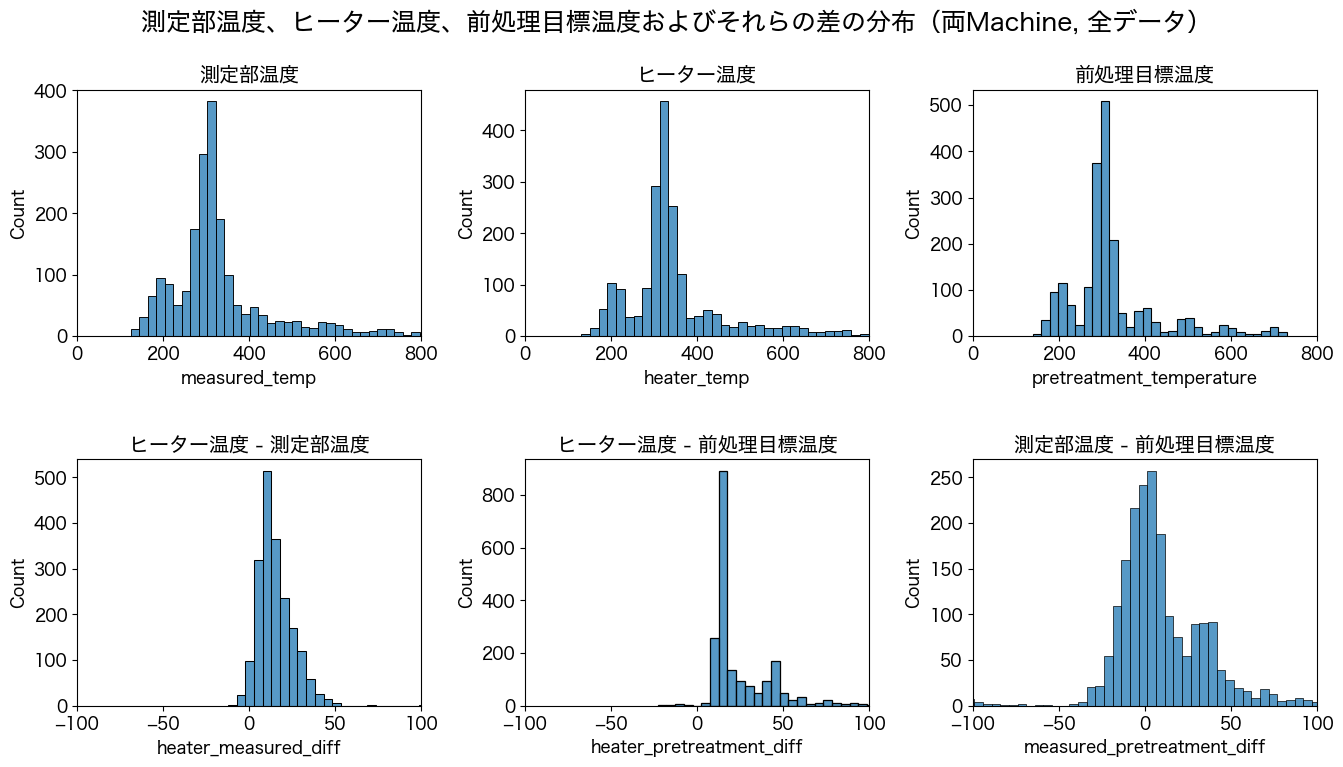

In [37]:
create_histgram_pretreattemp(
    summary_df, 
    title="測定部温度、ヒーター温度、前処理目標温度およびそれらの差の分布（両Machine, 全データ）", 
    savedir = os.path.join(OUTPUT_ROOT, "Graph/histgram"), 
    IS_SAVEGRAPH=False
)

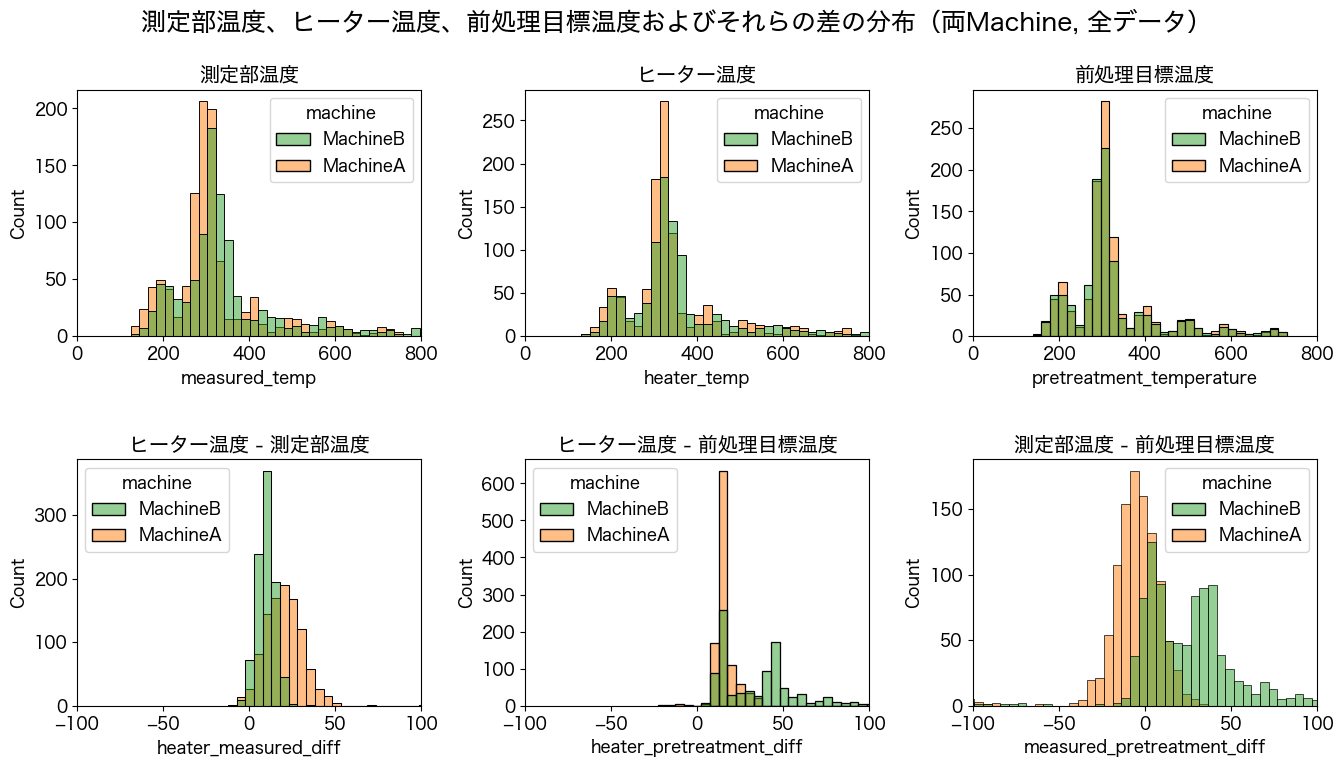

In [38]:
create_histgram_pretreattemp(
    summary_df, 
    title="測定部温度、ヒーター温度、前処理目標温度およびそれらの差の分布（両Machine, 全データ）", 
    huecolumn="machine",
    savedir = os.path.join(OUTPUT_ROOT, "Graph/histgram"), 
    IS_SAVEGRAPH=True, namekeyword="coloredbymachine"
)

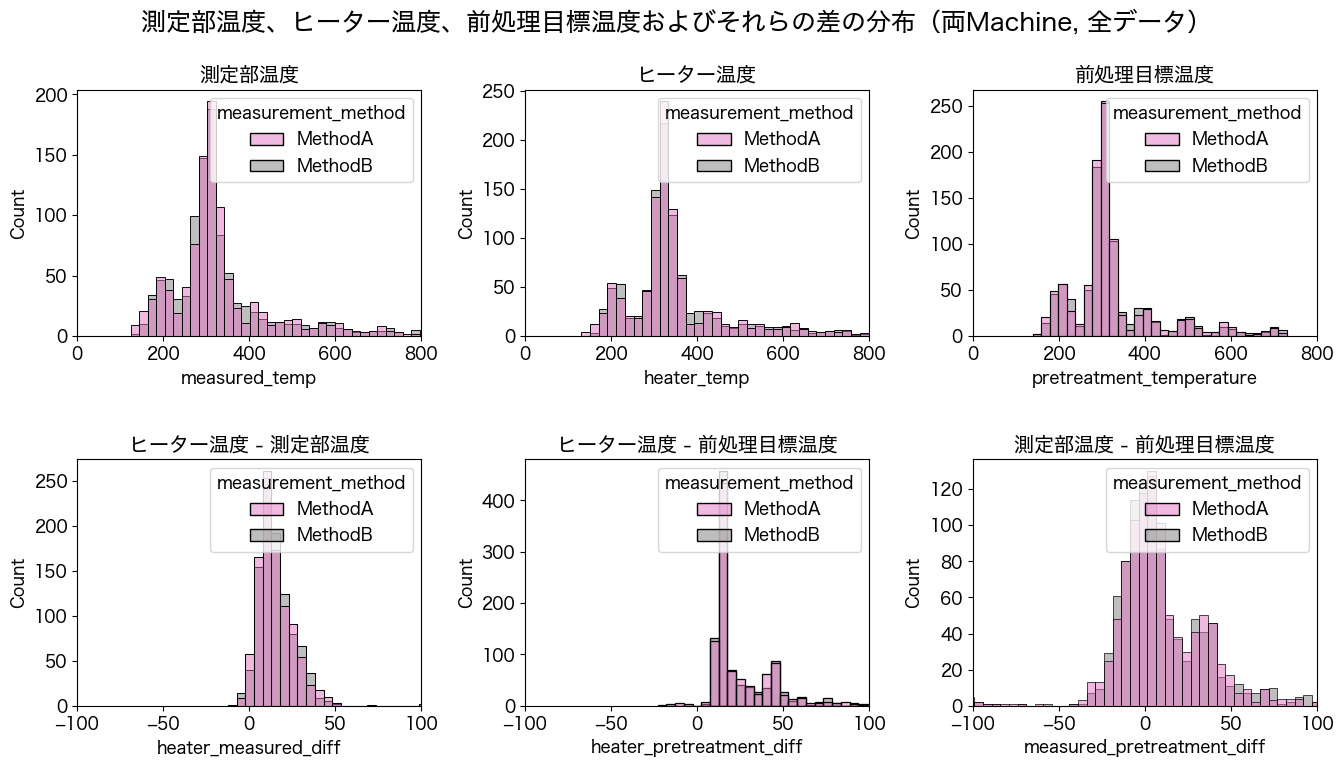

In [39]:
create_histgram_pretreattemp(
    summary_df, 
    title="測定部温度、ヒーター温度、前処理目標温度およびそれらの差の分布（両Machine, 全データ）", 
    huecolumn="measurement_method",
    savedir = os.path.join(OUTPUT_ROOT, "Graph/histgram"), 
    IS_SAVEGRAPH=False, namekeyword="coloredbymethod"
)

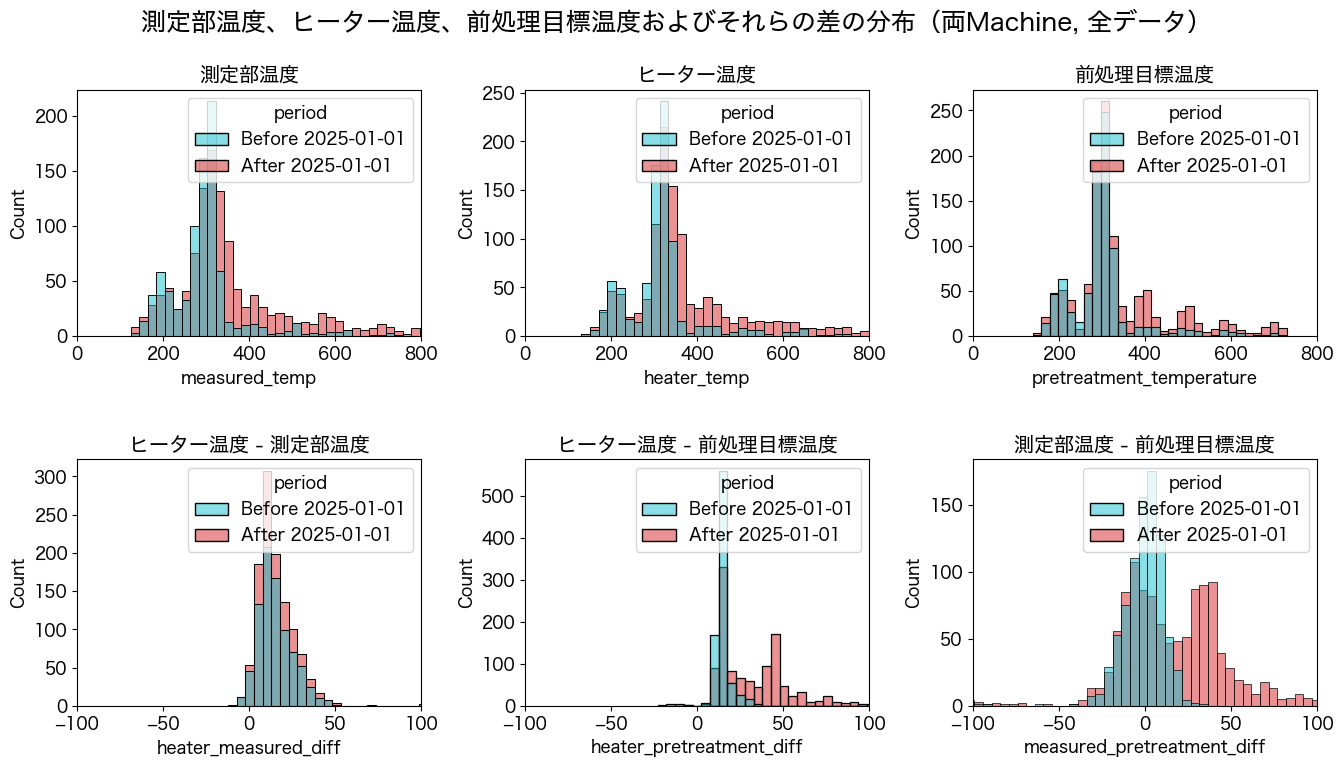

In [40]:
create_histgram_pretreattemp(
    summary_df, 
    title="測定部温度、ヒーター温度、前処理目標温度およびそれらの差の分布（両Machine, 全データ）", 
    huecolumn="period",
    savedir = os.path.join(OUTPUT_ROOT, "Graph/histgram"), 
    IS_SAVEGRAPH=False, namekeyword="coloredbyperiod"
)

(-50.0, 100.0)

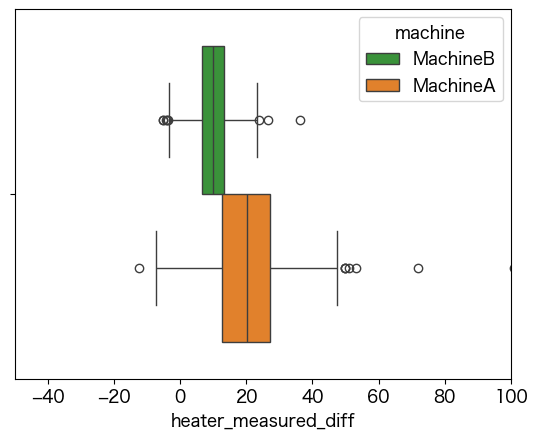

In [41]:
sns.boxplot(summary_df, x="heater_measured_diff", hue="machine", palette=CATEGORY_COLOR_MAP)
plt.xlim(-50, 100)

## MachineA/B × 2025年以前/以後の測定部温度 - 前処理目標温度分布

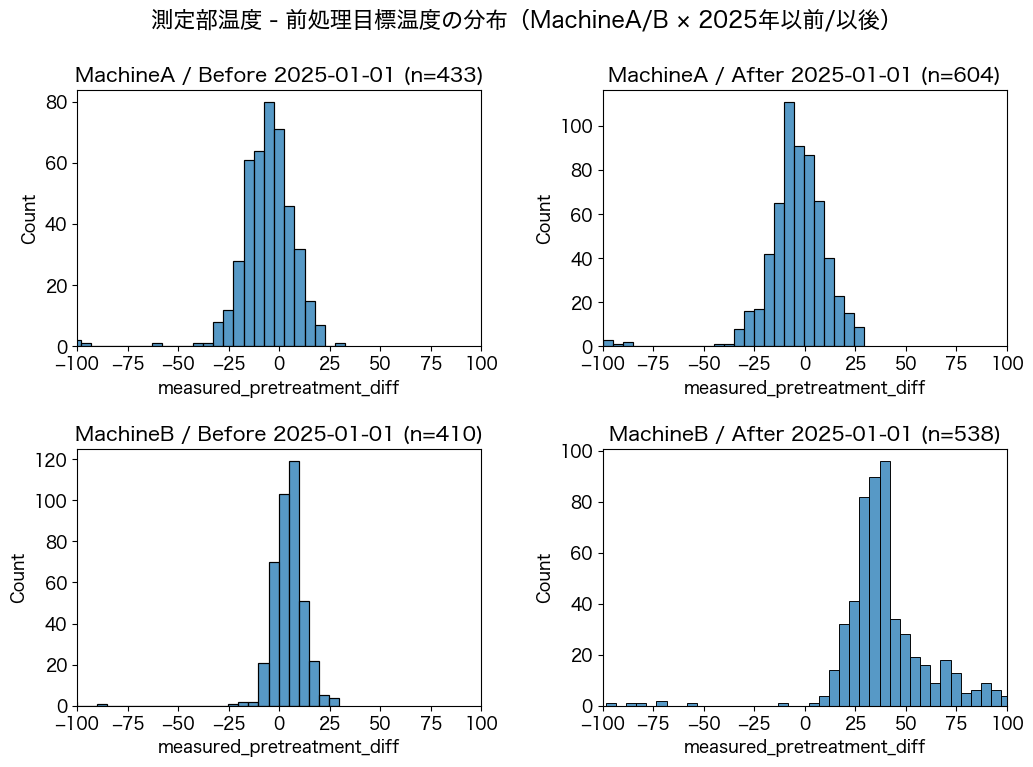

In [42]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

machines = ['MachineA', 'MachineB']
periods = ['Before 2025-01-01', 'After 2025-01-01']

for row, machine in enumerate(machines):
    for col, period in enumerate(periods):
        target_df = summary_df[(summary_df['machine'] == machine) & (summary_df['period'] == period)]
        sns.histplot(target_df, x="measured_pretreatment_diff", binwidth=5, color="tab:blue", ax=axs[row, col])
        axs[row, col].set_xlim(-100, 100)
        axs[row, col].set_title(f"{machine} / {period} (n={len(target_df)})")

plt.suptitle("測定部温度 - 前処理目標温度の分布（MachineA/B × 2025年以前/以後）", fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

## Scatter Plot: 横軸年

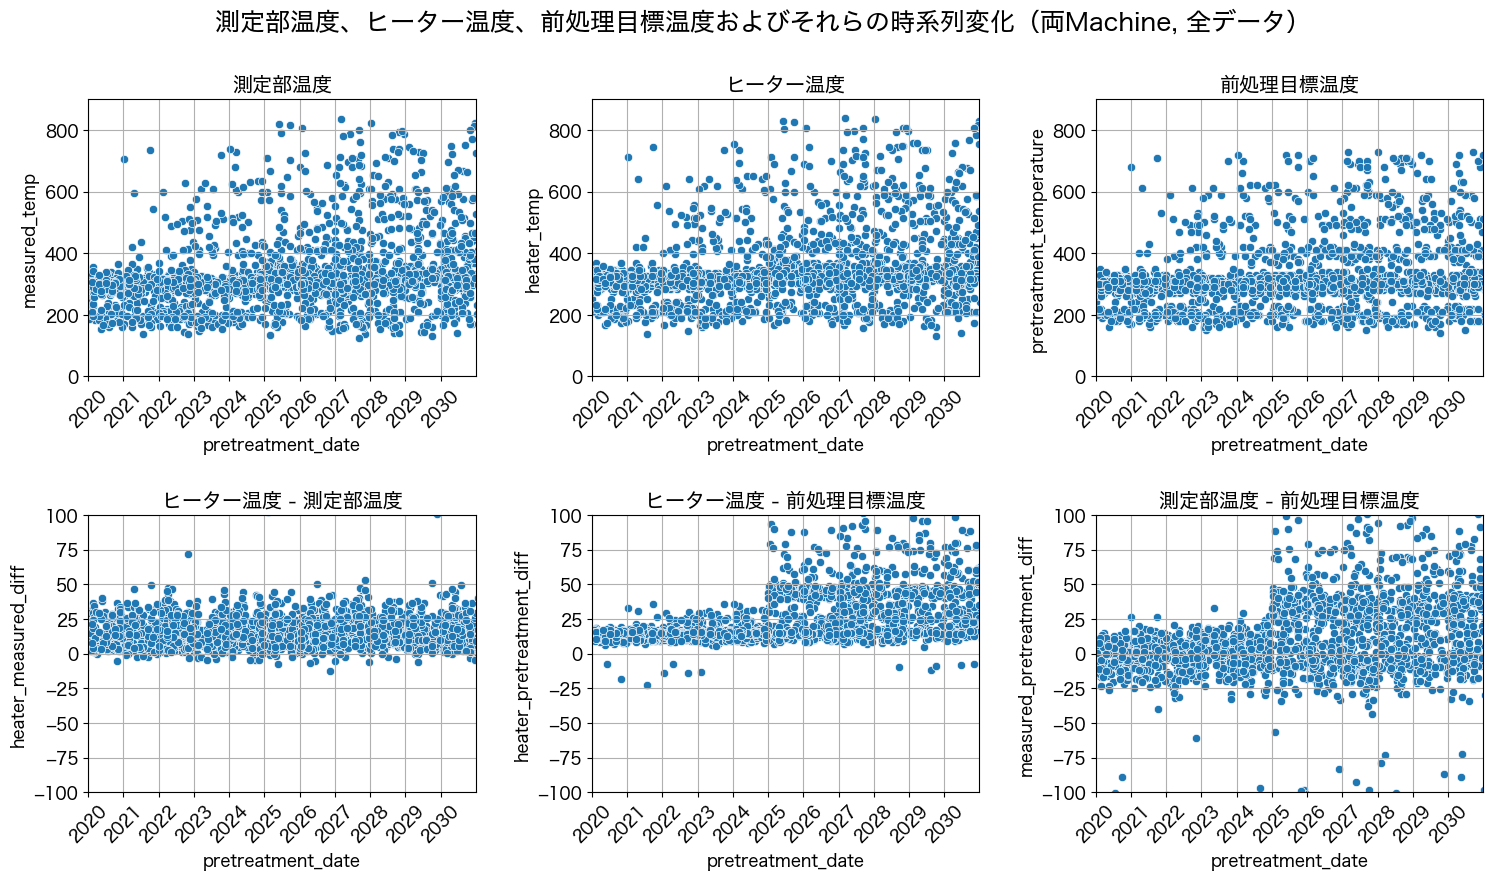

In [43]:
create_scatterplot_date_vs_pretreatmenttemp(summary_df, 
                                            title="測定部温度、ヒーター温度、前処理目標温度およびそれらの時系列変化（両Machine, 全データ）",
                                            savedir=os.path.join(OUTPUT_ROOT, "Graph/date_vs_temp"),
                                           IS_SAVEGRAPH=True)

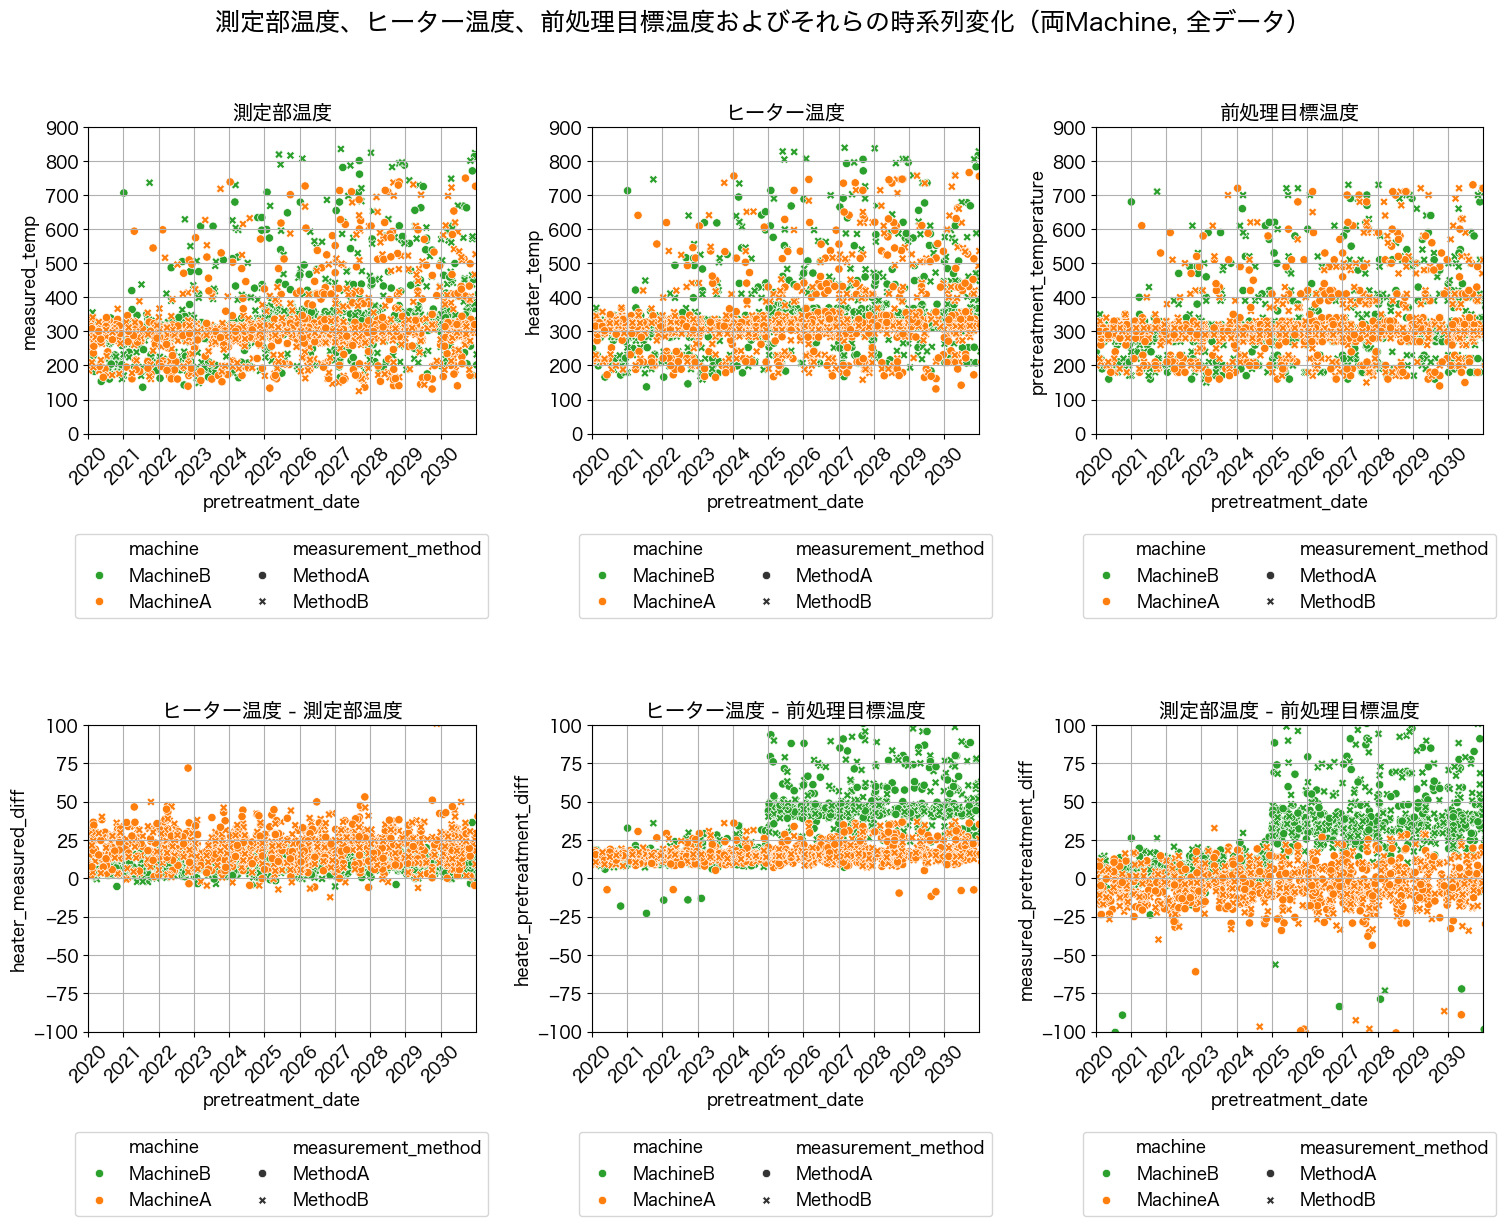

In [44]:
create_scatterplot_date_vs_pretreatmenttemp(summary_df, 
                                            title="測定部温度、ヒーター温度、前処理目標温度およびそれらの時系列変化（両Machine, 全データ）",
                                            huecolumn="machine", stylecolumn='measurement_method',
                                            savedir=os.path.join(OUTPUT_ROOT, "Graph/date_vs_temp"),
                                           IS_SAVEGRAPH=True, namekeyword='coloredbymachineanddatatype')

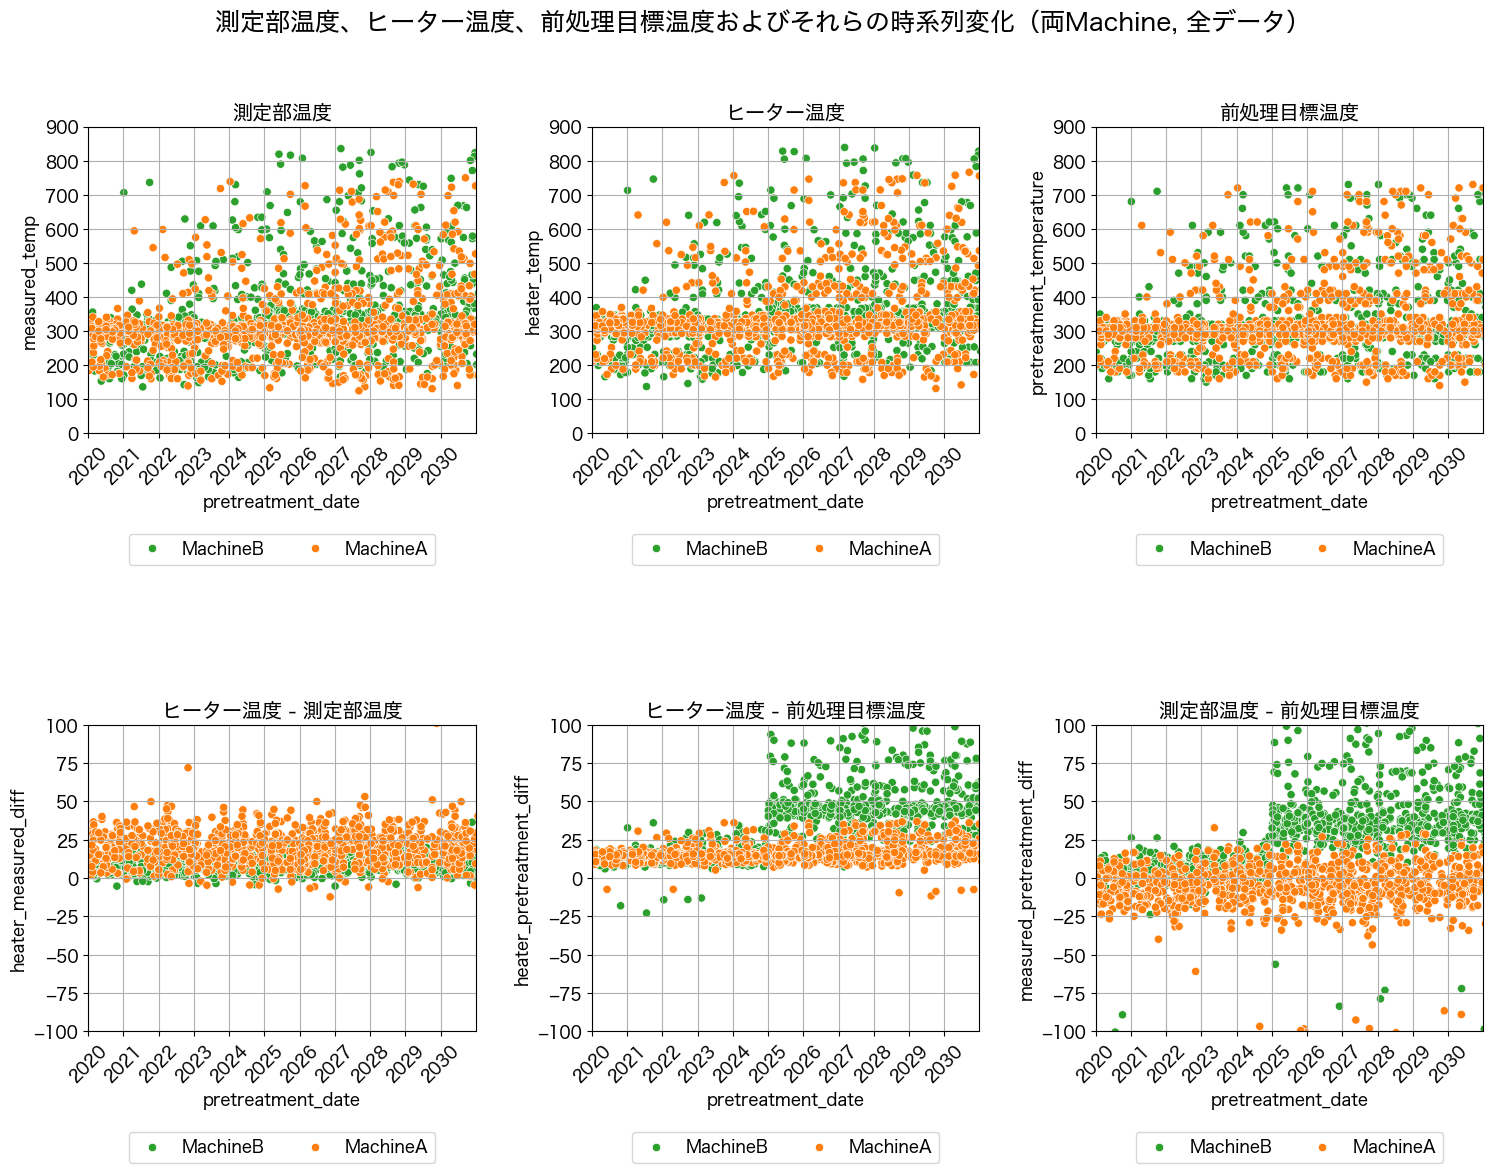

In [45]:
create_scatterplot_date_vs_pretreatmenttemp(summary_df, 
                                            title="測定部温度、ヒーター温度、前処理目標温度およびそれらの時系列変化（両Machine, 全データ）",
                                            huecolumn="machine",
                                            savedir=os.path.join(OUTPUT_ROOT, "Graph/date_vs_temp"),
                                           IS_SAVEGRAPH=True, namekeyword='coloredbymachine')

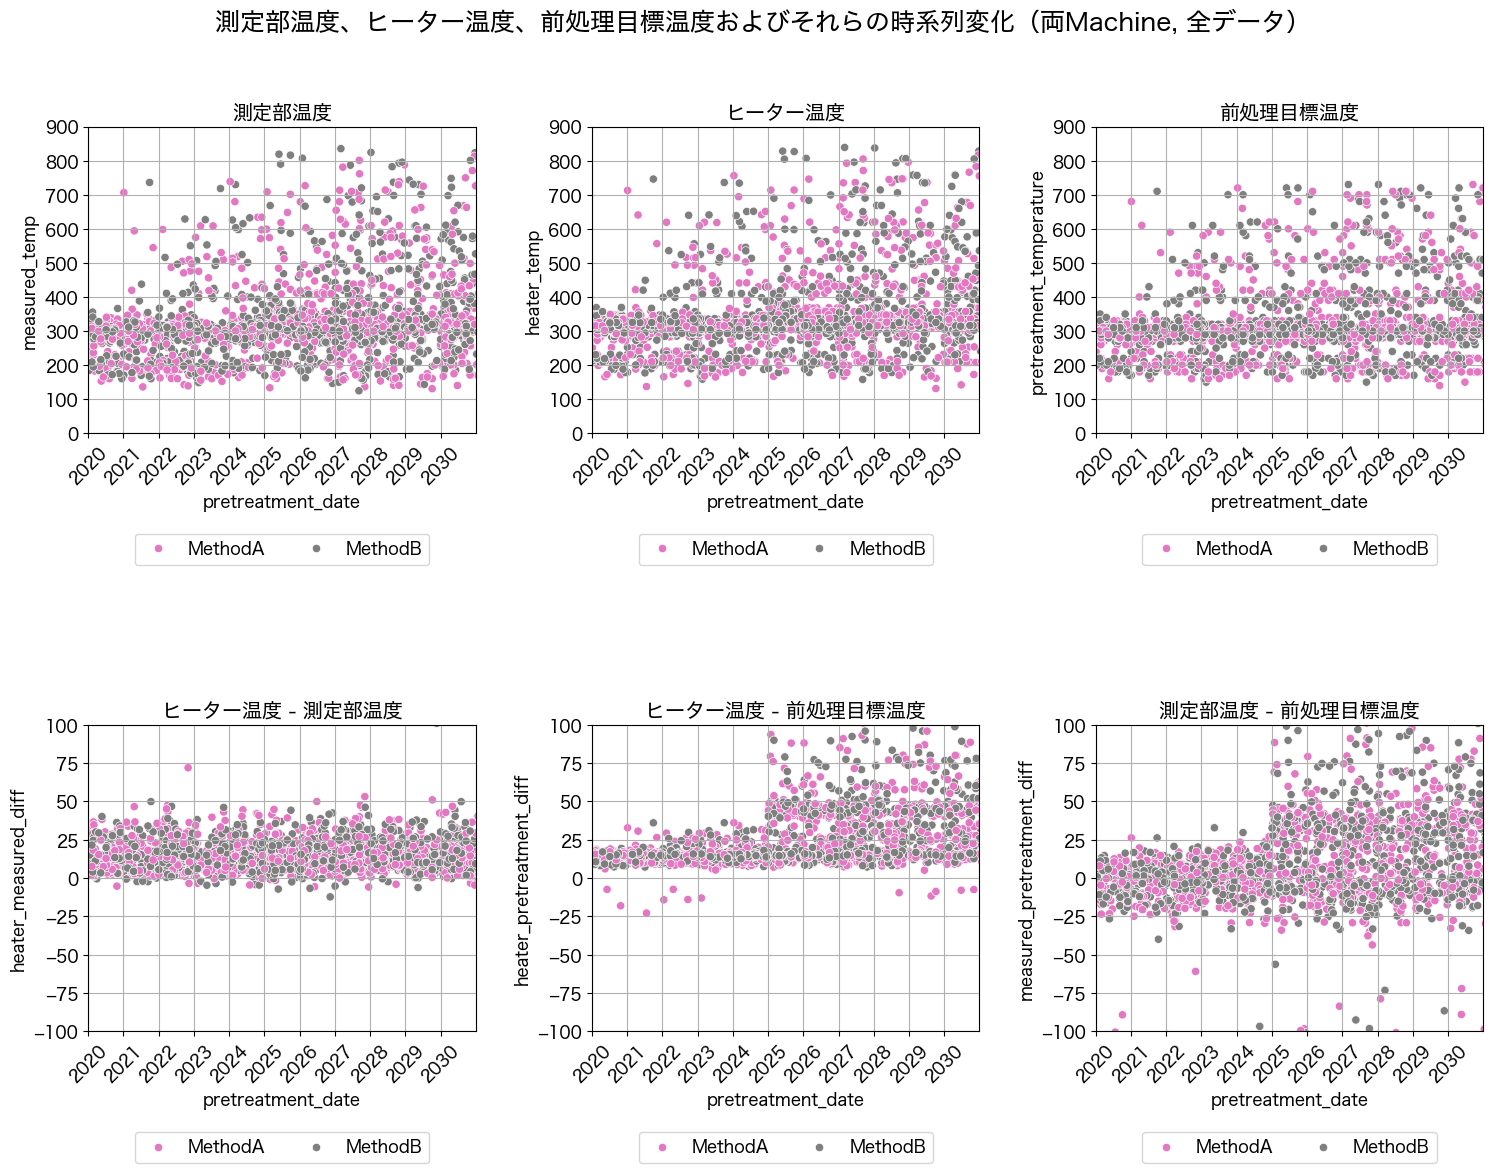

In [46]:
create_scatterplot_date_vs_pretreatmenttemp(summary_df, 
                                            title="測定部温度、ヒーター温度、前処理目標温度およびそれらの時系列変化（両Machine, 全データ）",
                                            huecolumn="measurement_method",
                                            savedir=os.path.join(OUTPUT_ROOT, "Graph/date_vs_temp"),
                                           IS_SAVEGRAPH=True, namekeyword='coloredbydatatype')

## Scatter Plot: 横軸温度

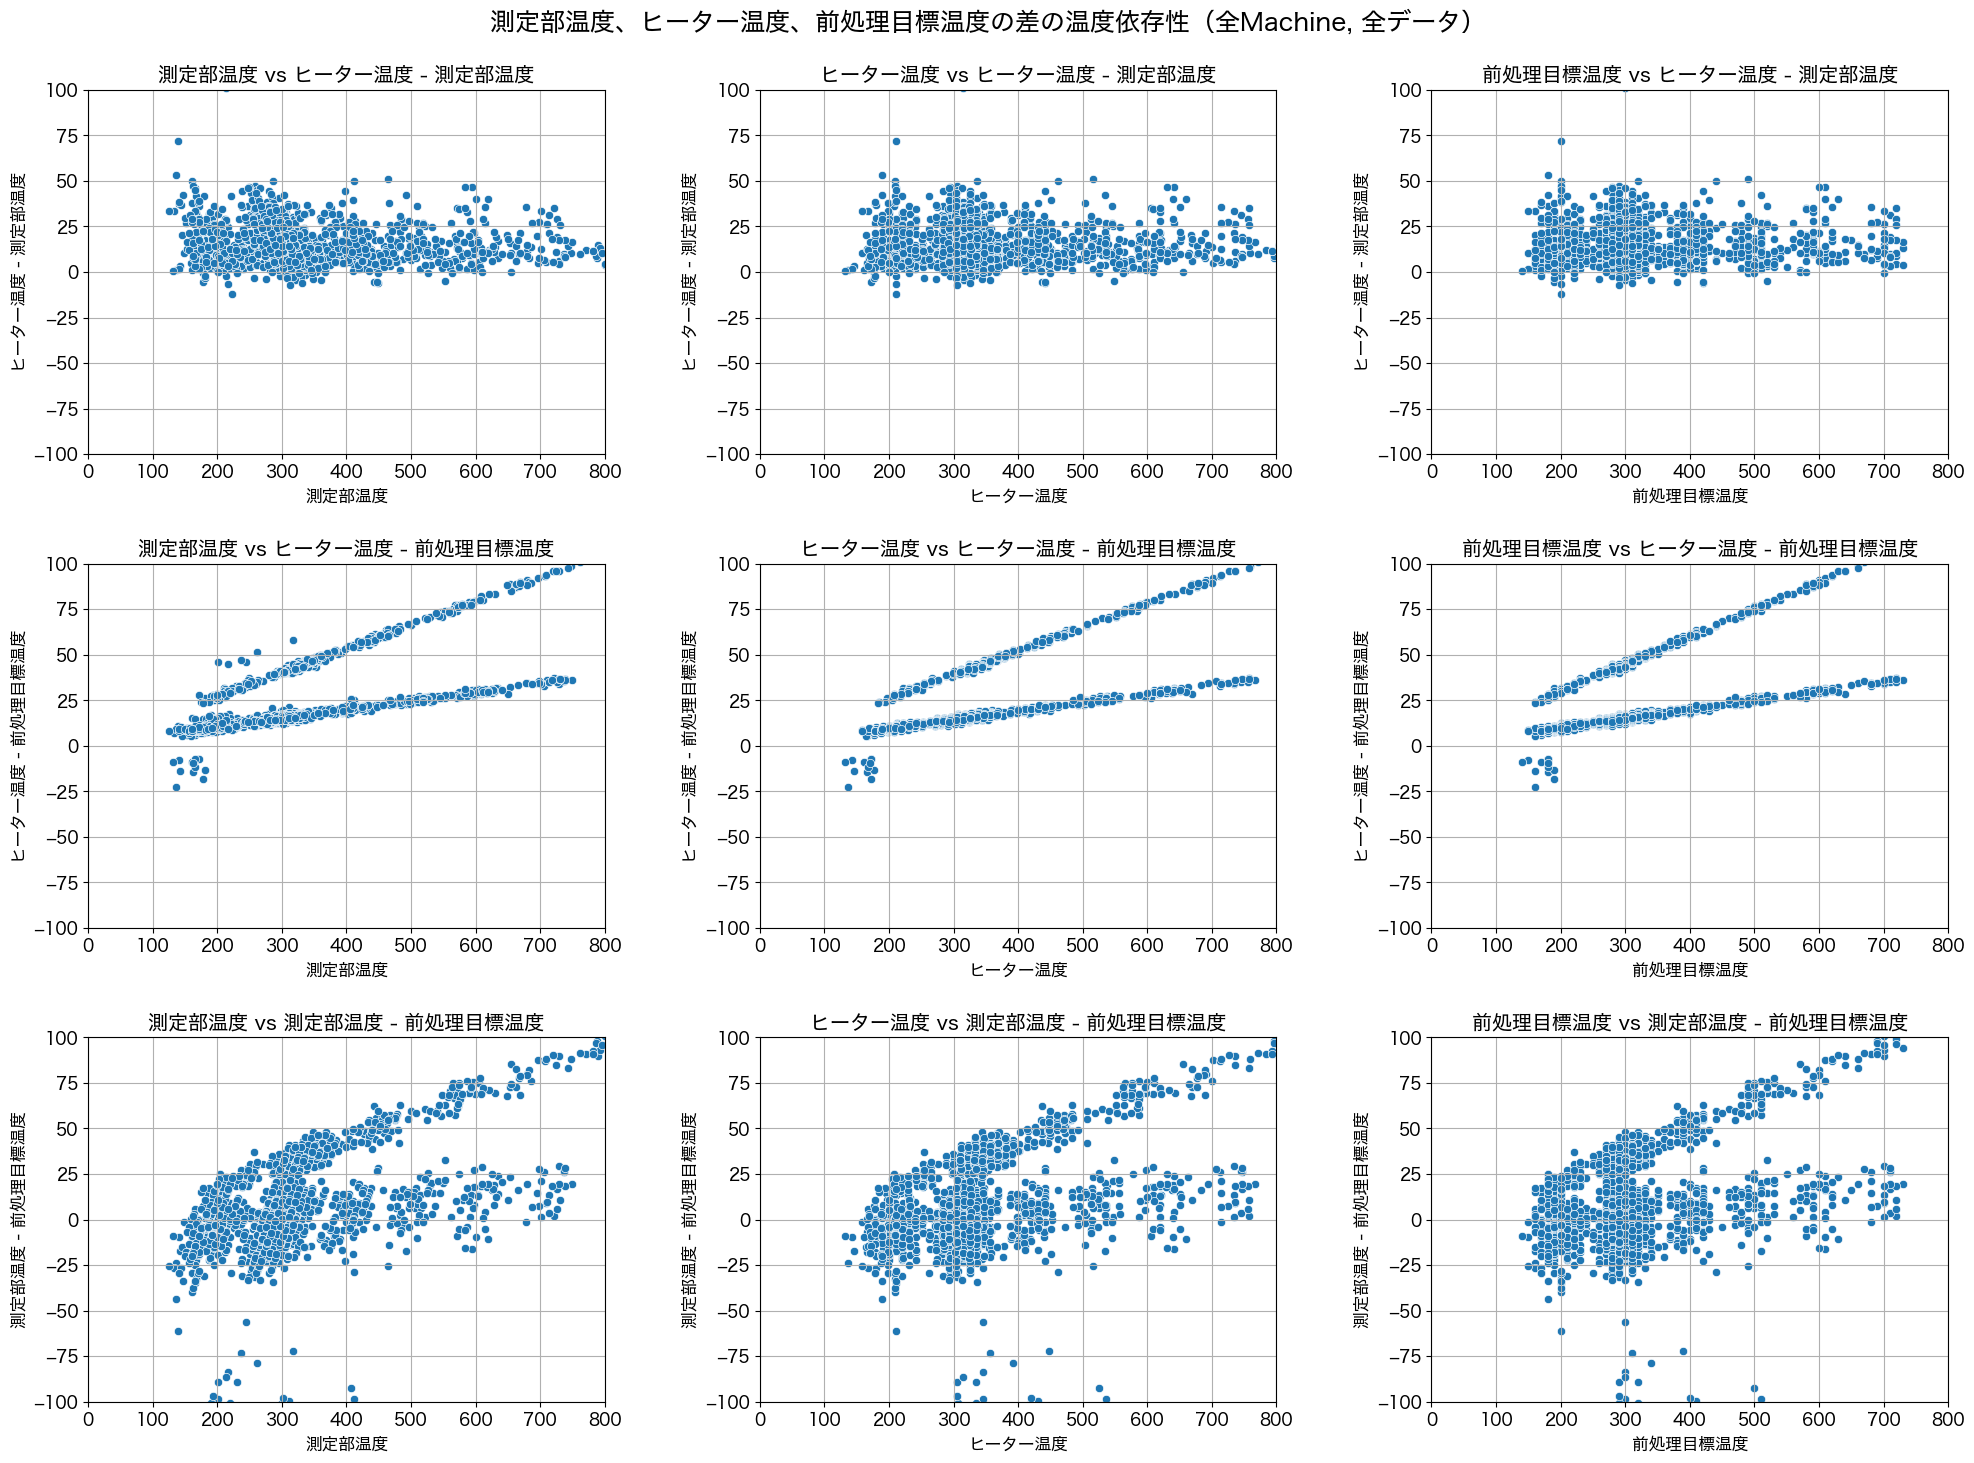

In [47]:
create_scatterplot_pretreatmenttemp_vs_deltatemp(
    summary_df, 
    title="測定部温度、ヒーター温度、前処理目標温度の差の温度依存性（全Machine, 全データ）",
    savedir=os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp"),
    IS_SAVEGRAPH=True)

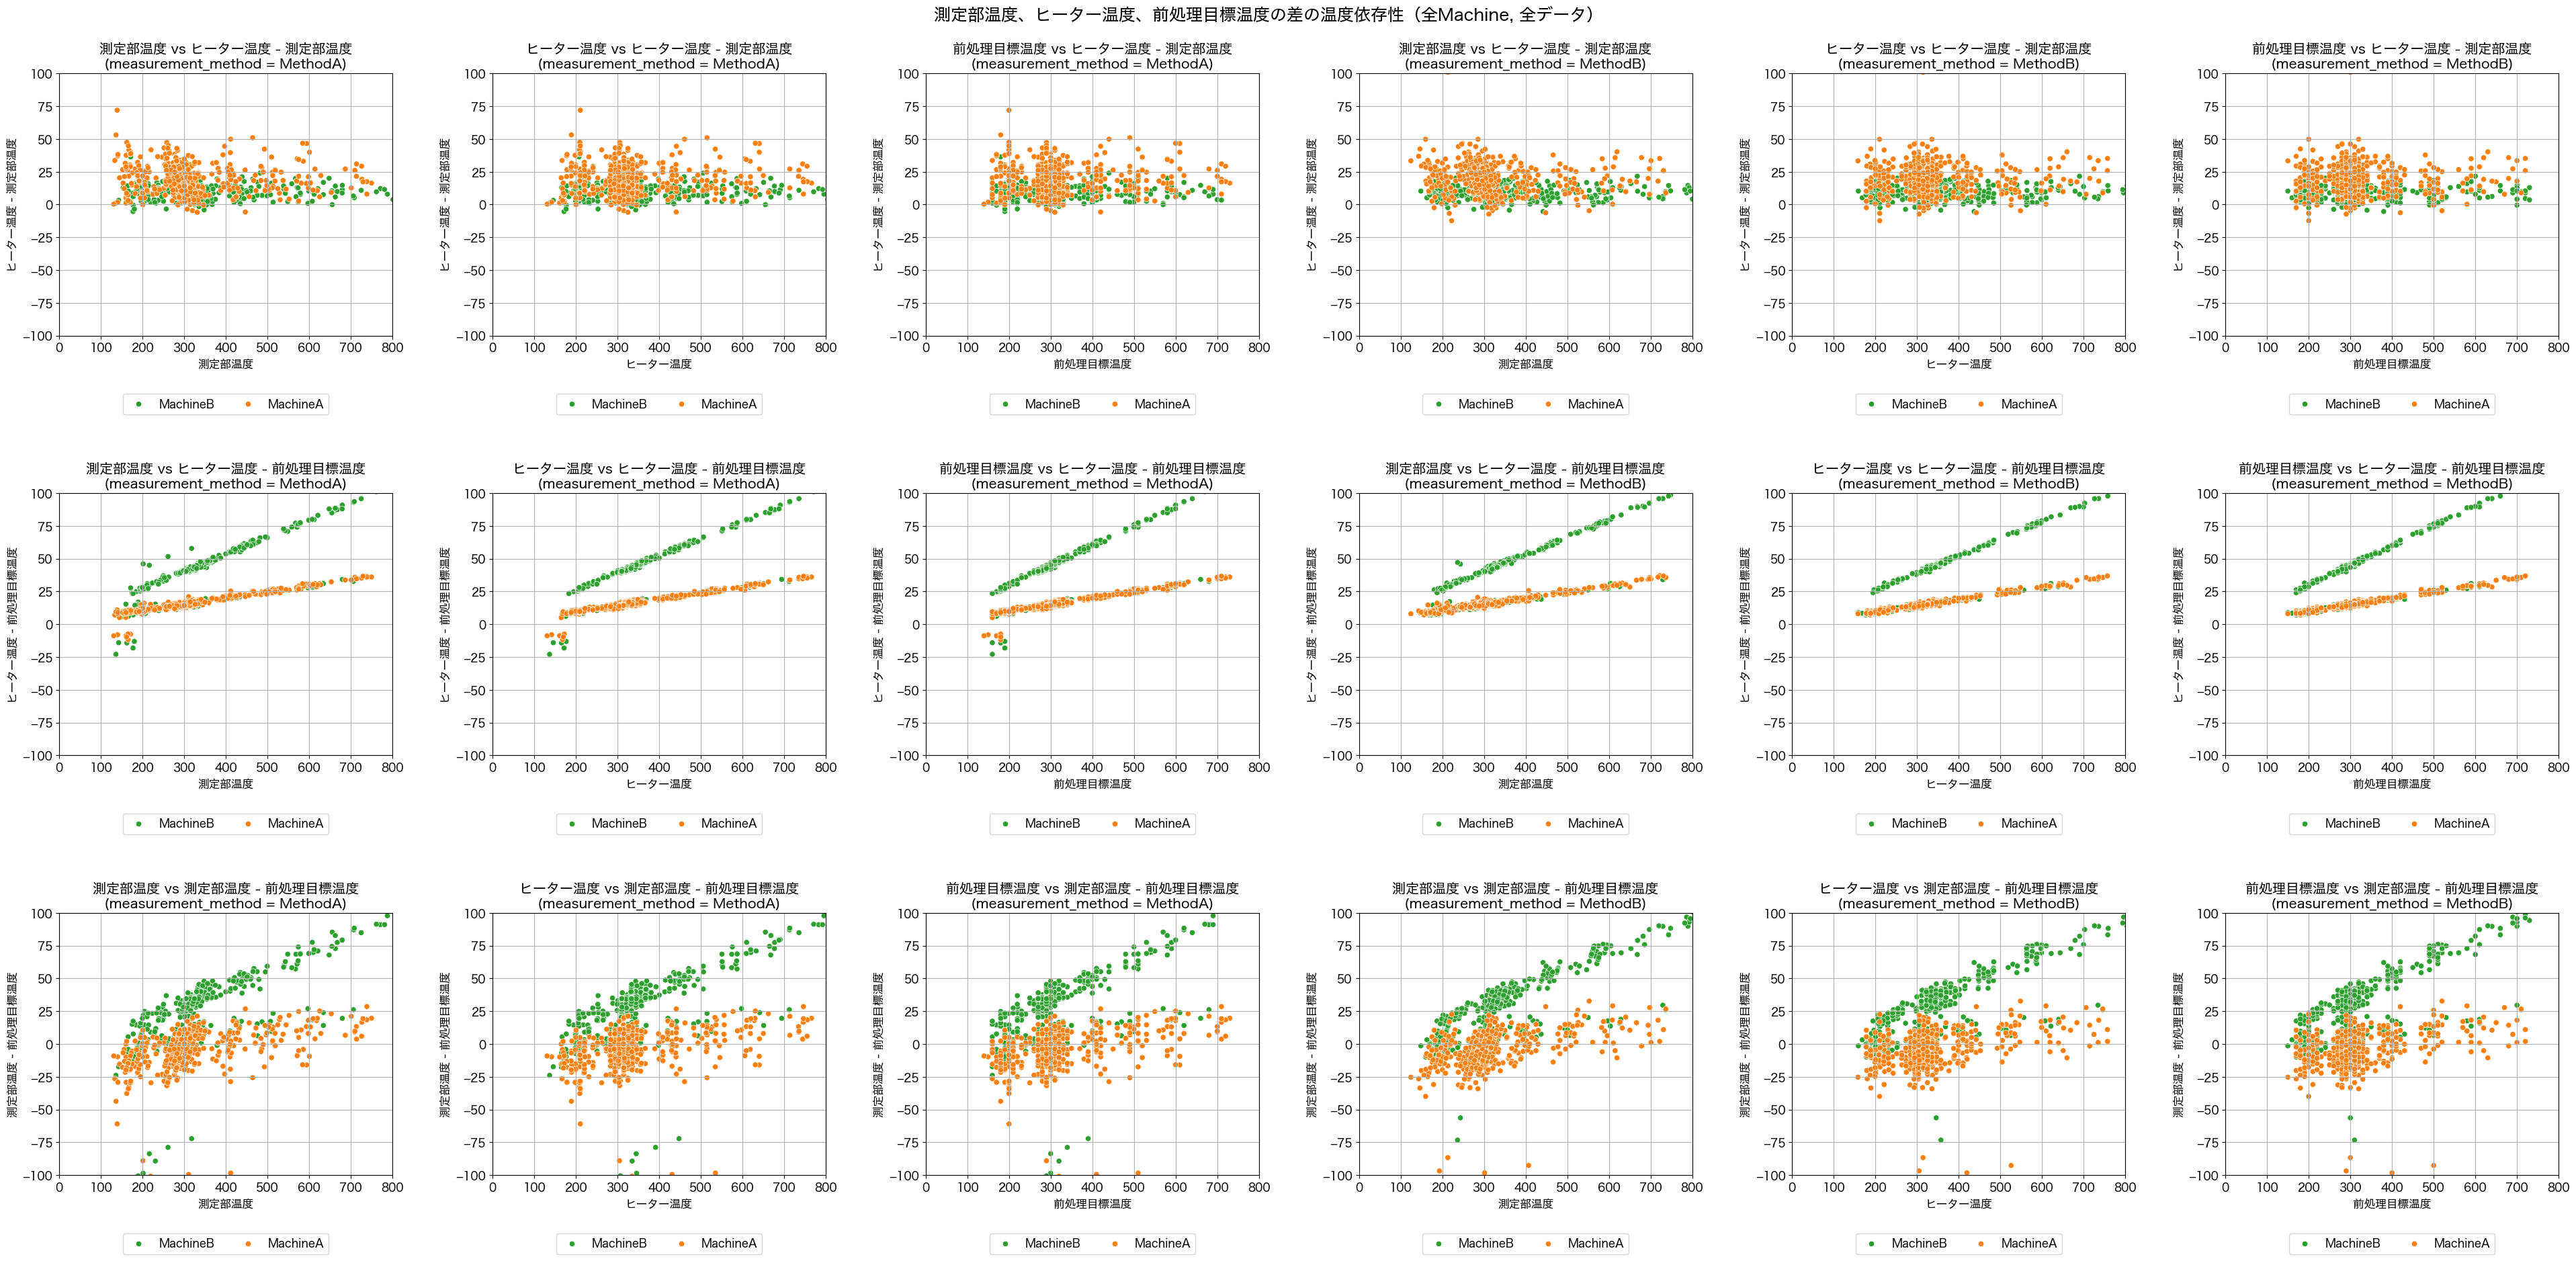

In [48]:
create_scatterplot_pretreatmenttemp_vs_deltatemp(
    summary_df, huecolumn="machine", stylecolumn='measurement_method',
    title="測定部温度、ヒーター温度、前処理目標温度の差の温度依存性（全Machine, 全データ）",
    savedir=os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp"),
    IS_SAVEGRAPH=True, namekeyword='colormachinedtype')

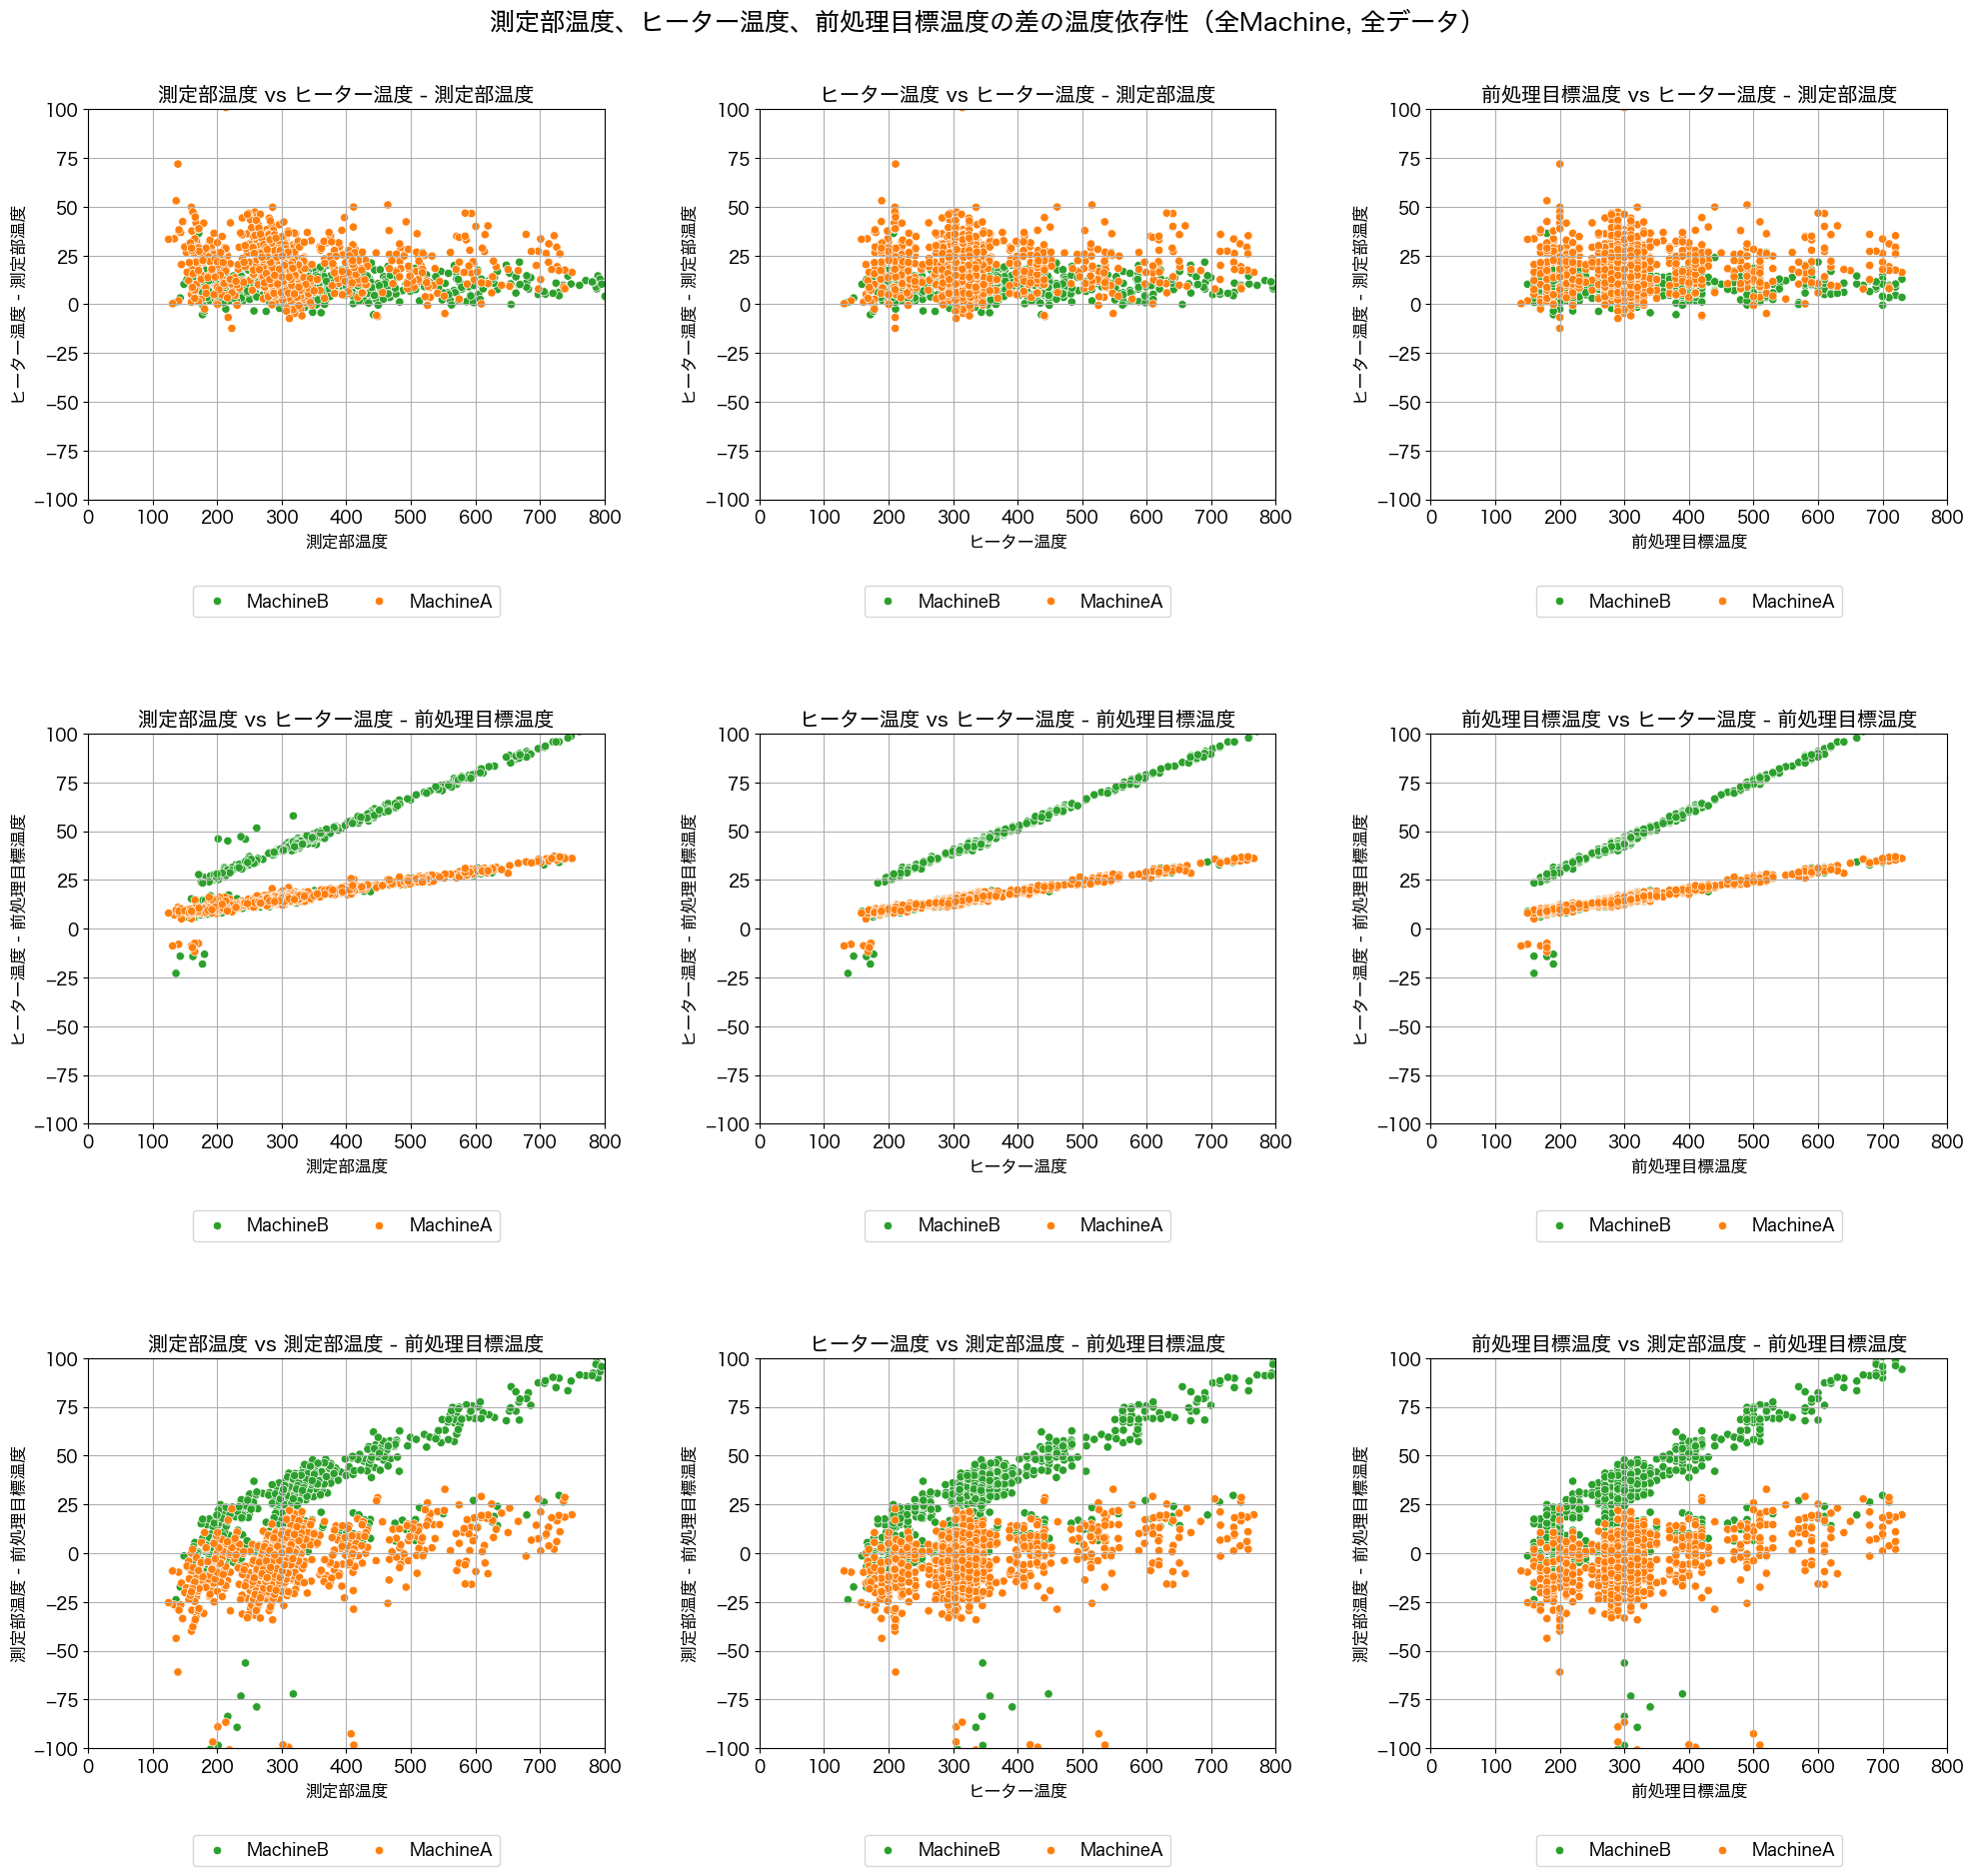

In [49]:
create_scatterplot_pretreatmenttemp_vs_deltatemp(
    summary_df, huecolumn="machine",
    title="測定部温度、ヒーター温度、前処理目標温度の差の温度依存性（全Machine, 全データ）",
    savedir=os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp"),
    IS_SAVEGRAPH=True, namekeyword='coloredbymachine')

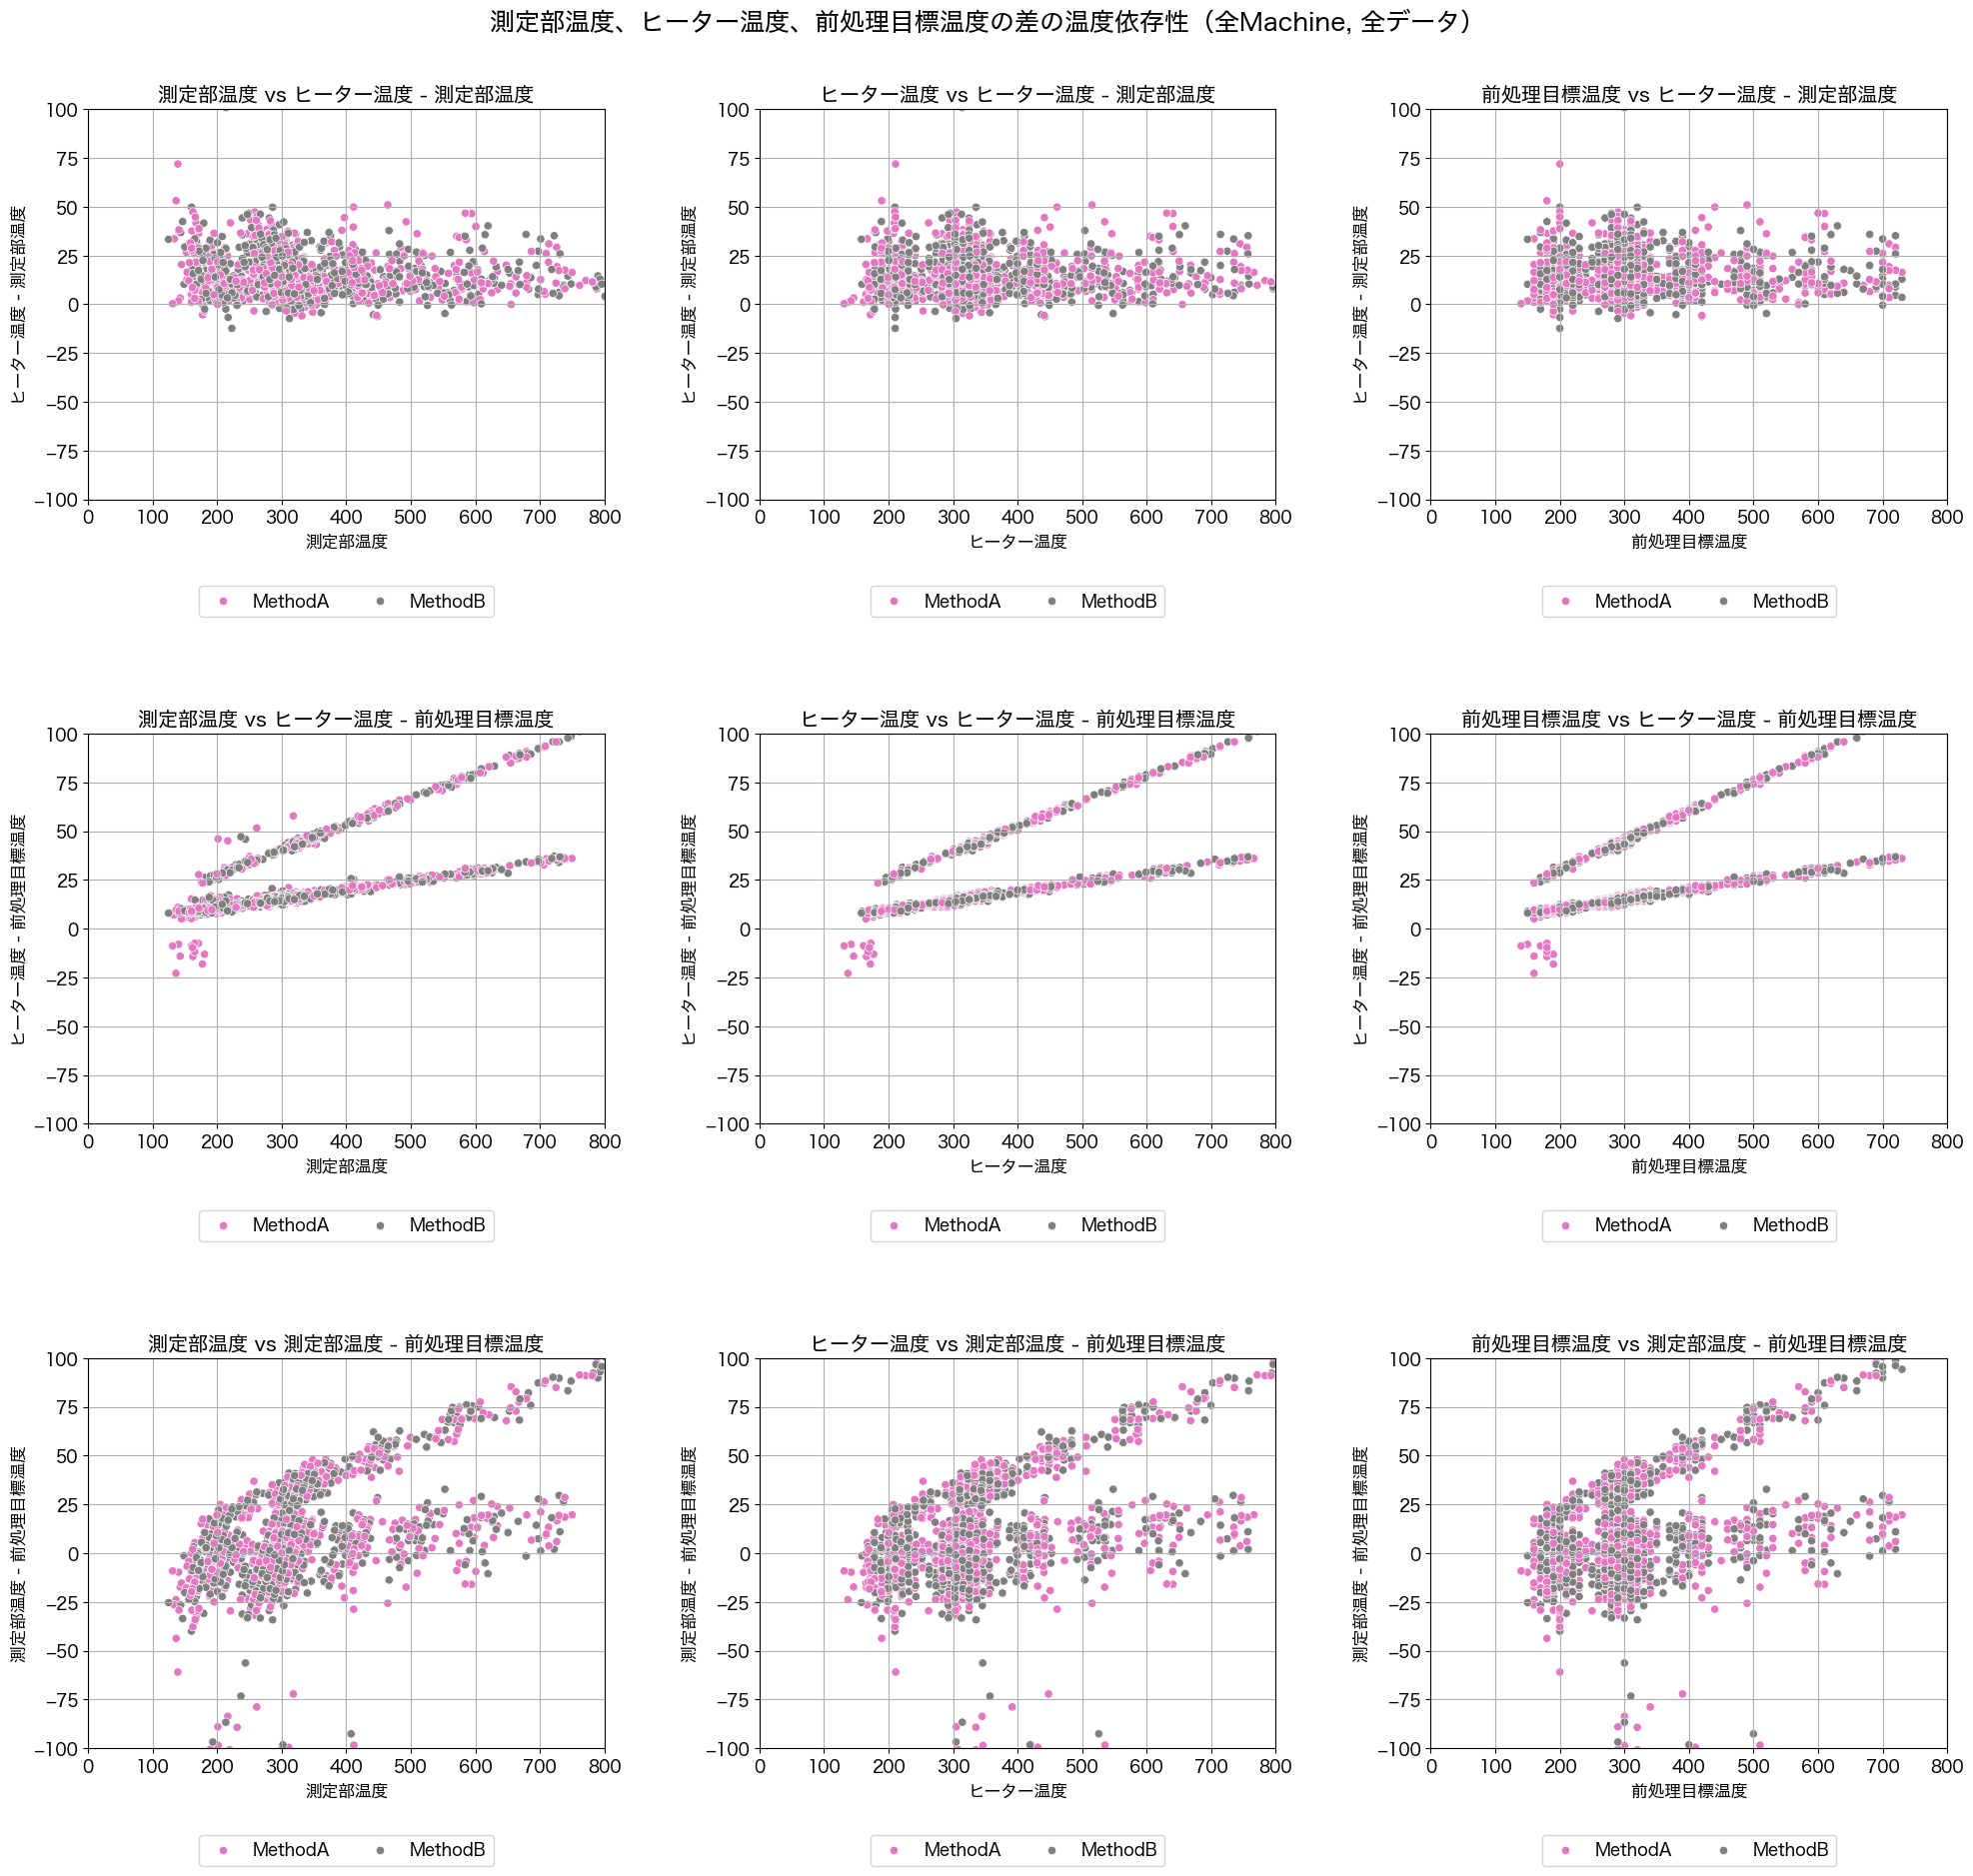

In [50]:
create_scatterplot_pretreatmenttemp_vs_deltatemp(
    summary_df, huecolumn="measurement_method",
    title="測定部温度、ヒーター温度、前処理目標温度の差の温度依存性（全Machine, 全データ）",
    savedir=os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp"),
    IS_SAVEGRAPH=True, namekeyword='coloredbydtype')

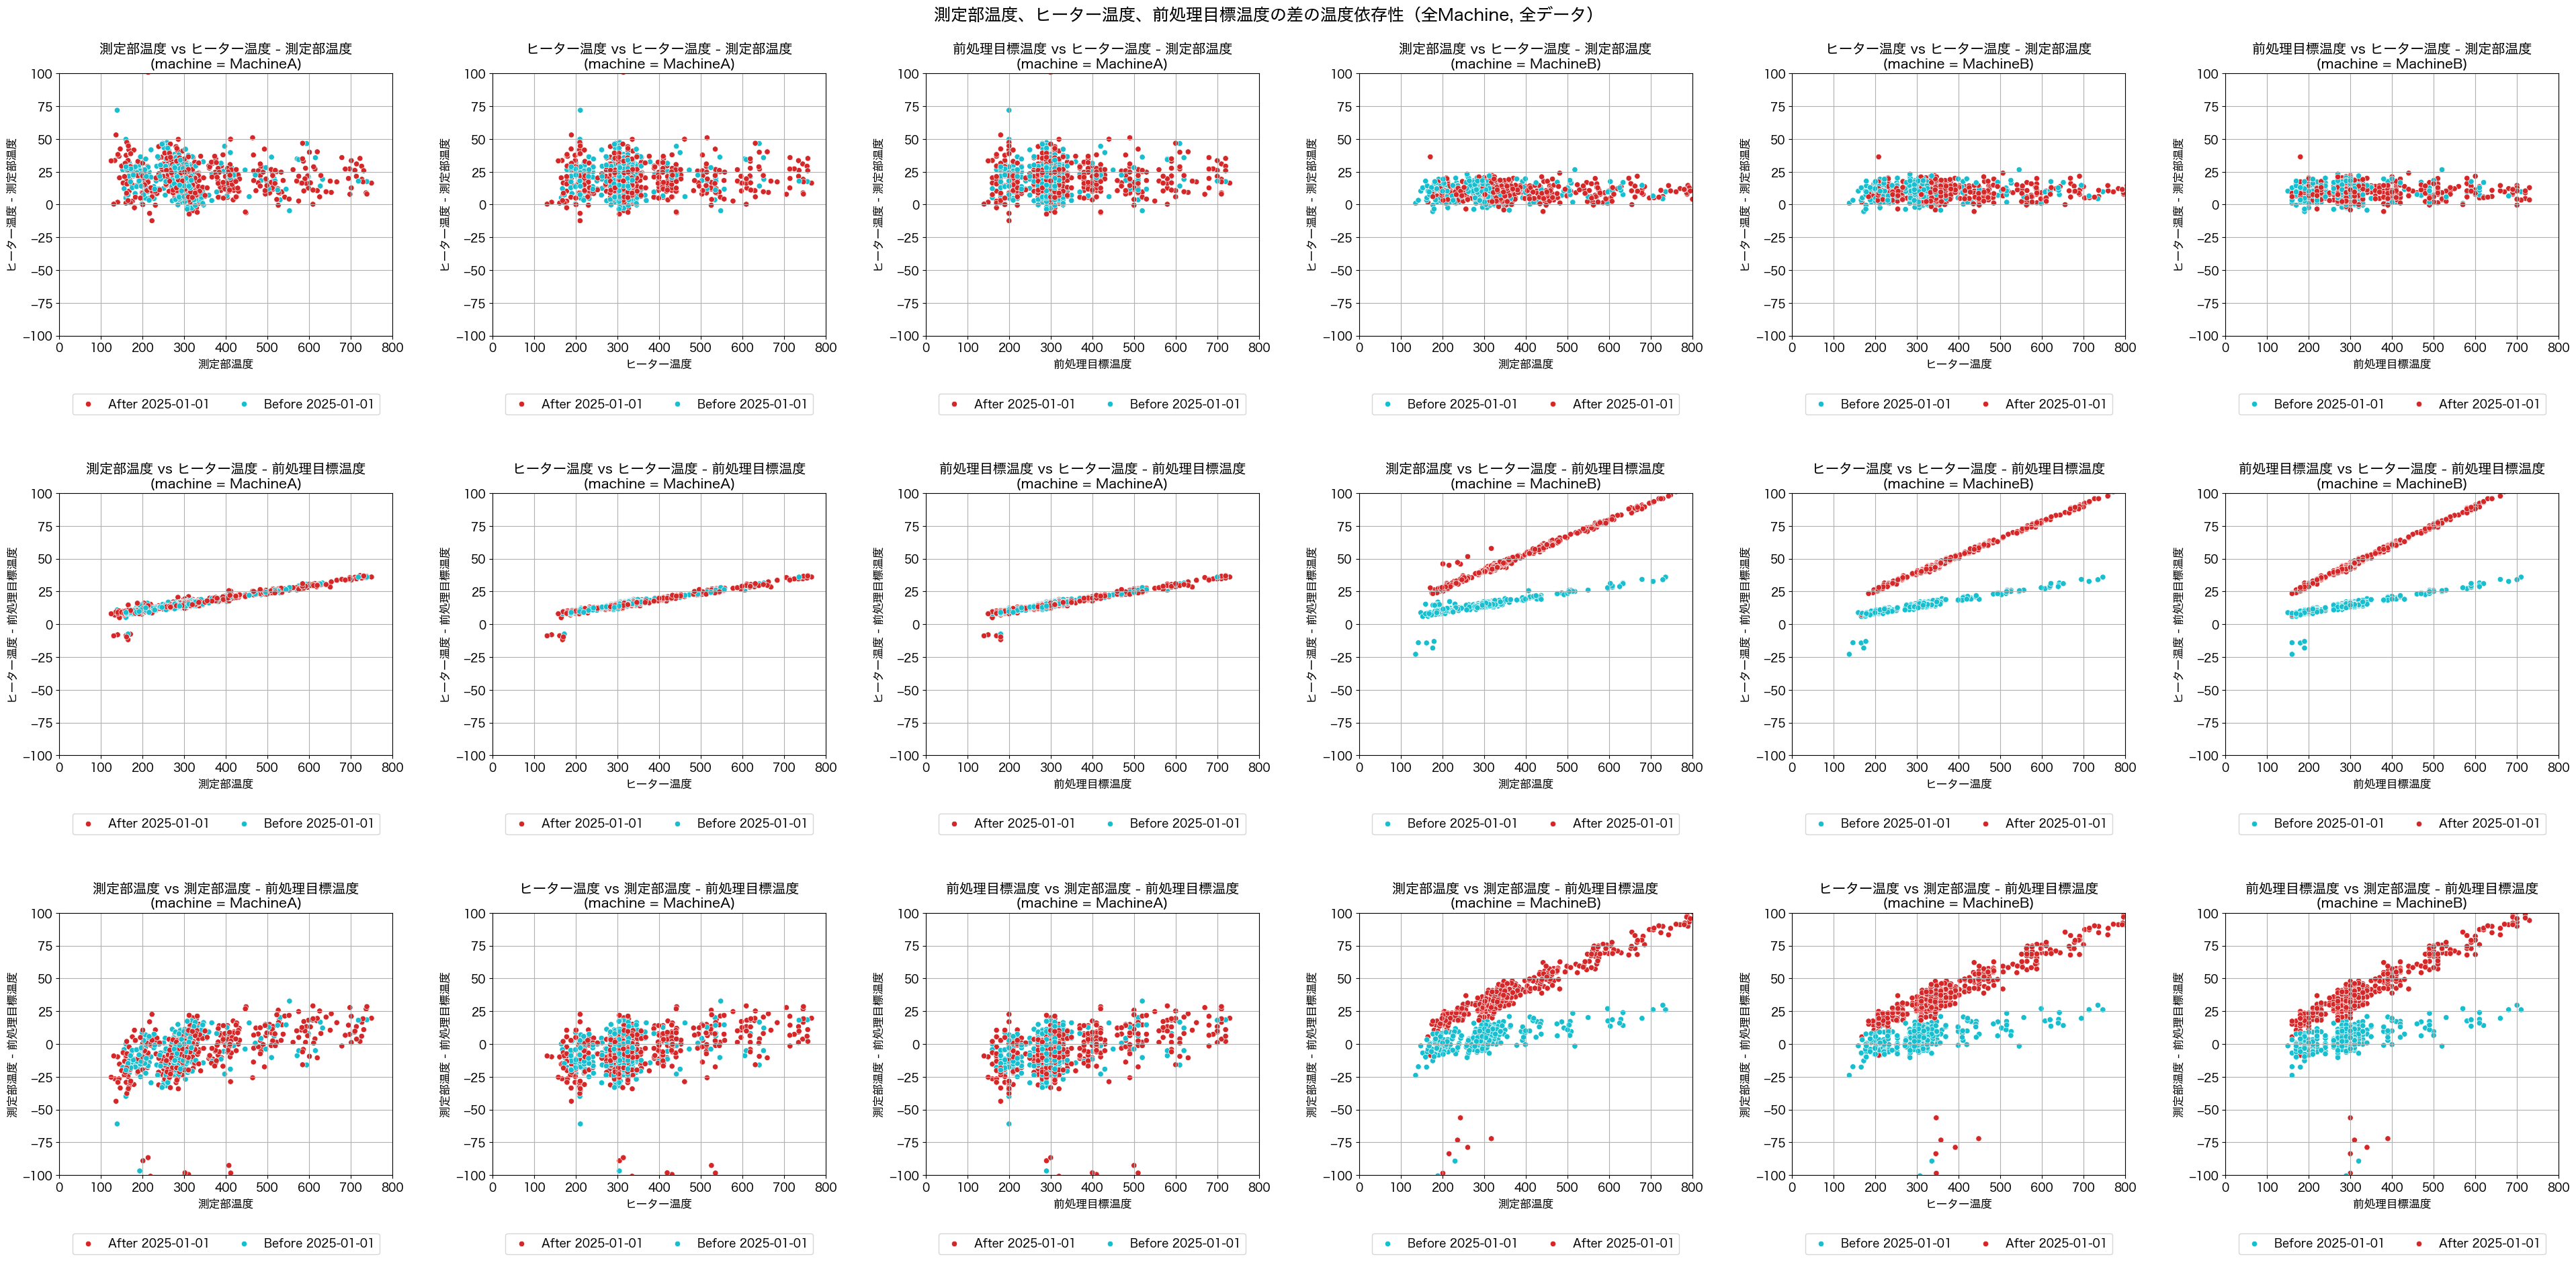

In [51]:
create_scatterplot_pretreatmenttemp_vs_deltatemp(
    summary_df, huecolumn="period", stylecolumn='machine',
    title="測定部温度、ヒーター温度、前処理目標温度の差の温度依存性（全Machine, 全データ）",
    savedir=os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp"),
    IS_SAVEGRAPH=True, namekeyword='colorperibel')

## MachineA/B × Period別の詳細分析

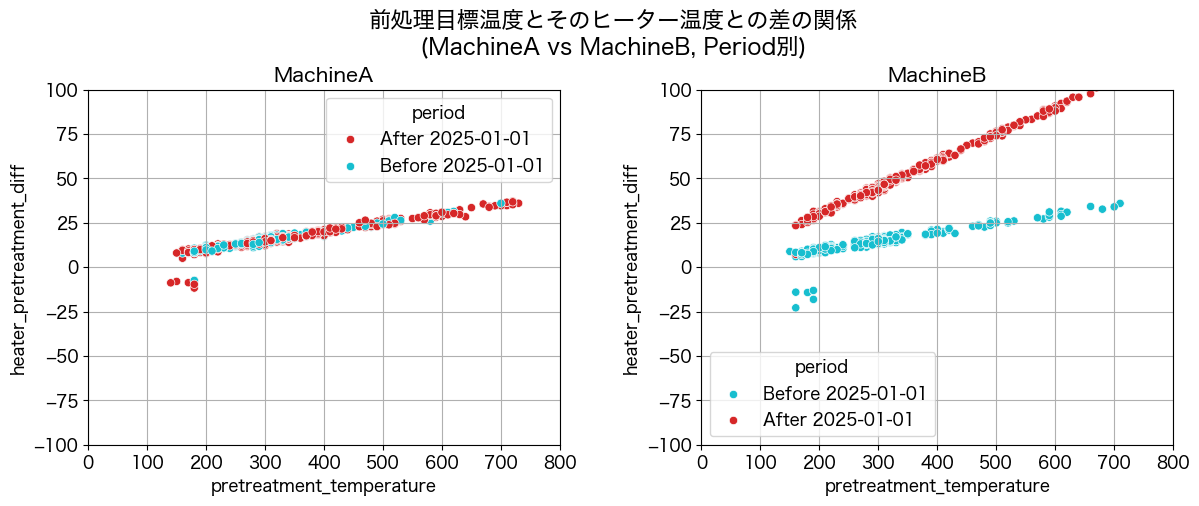

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

machines = ['MachineA', 'MachineB']

for col, machine in enumerate(machines):
    target_df = summary_df[summary_df['machine'] == machine]
    sns.scatterplot(target_df, x="pretreatment_temperature", y="heater_pretreatment_diff", hue='period', palette=CATEGORY_COLOR_MAP, ax=axs[col])
    axs[col].set_xlim(0, 800)
    axs[col].set_ylim(-100, 100)
    axs[col].set_title(machine)
    axs[col].grid()

plt.suptitle("前処理目標温度とそのヒーター温度との差の関係\n(MachineA vs MachineB, Period別)", fontsize=16)
plt.subplots_adjust(wspace=0.3, top=0.82)

if IS_SAVEGRAPH:
    graph_save_path = os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp/pretemp_vs_diffheaterpretemp/from20250101toCurrent_3.png")
    os.makedirs(os.path.dirname(graph_save_path), exist_ok=True)
    plt.savefig(graph_save_path, bbox_inches="tight")
else:
    plt.show()

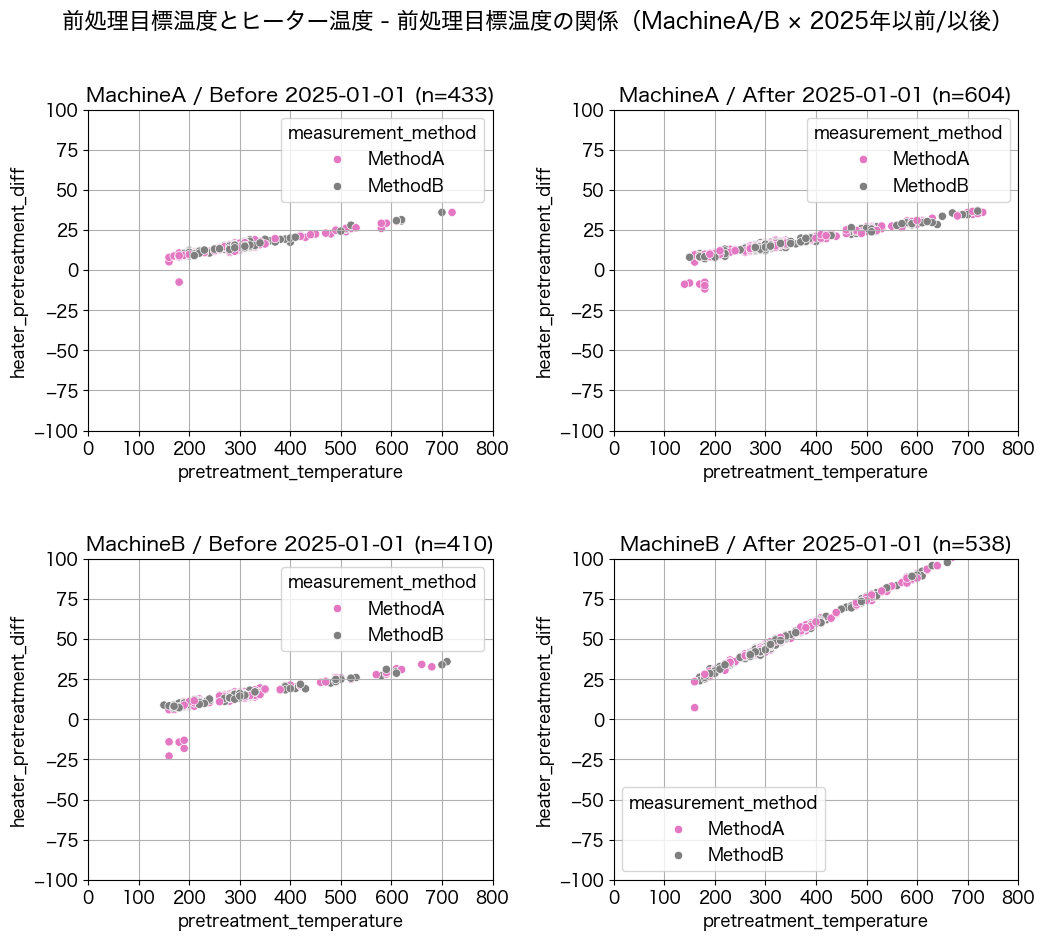

In [53]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

machines = ['MachineA', 'MachineB']
periods = ['Before 2025-01-01', 'After 2025-01-01']

for row, machine in enumerate(machines):
    for col, period in enumerate(periods):
        target_df = summary_df[(summary_df['machine'] == machine) & (summary_df['period'] == period)]
        sns.scatterplot(target_df, x="pretreatment_temperature", y="heater_pretreatment_diff", hue="measurement_method", palette=CATEGORY_COLOR_MAP, ax=axs[row, col])
        axs[row, col].set_xlim(0, 800)
        axs[row, col].set_ylim(-100, 100)
        axs[row, col].set_title(f"{machine} / {period} (n={len(target_df)})")
        axs[row, col].grid()

plt.suptitle("前処理目標温度とヒーター温度 - 前処理目標温度の関係（MachineA/B × 2025年以前/以後）", fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

if IS_SAVEGRAPH:
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    savedir = os.path.join(OUTPUT_ROOT, "Graph/temp_vs_deltatemp/pretemp_vs_diffheaterpretemp_machineperiod")
    os.makedirs(savedir, exist_ok=True)
    graph_save_path = os.path.join(savedir, f'scatterplot_pretemp_vs_diffheaterpretemp_machineperiod_created{current_time}.png')
    plt.savefig(graph_save_path, bbox_inches="tight")
else:
    plt.show()

### Temperature trend data

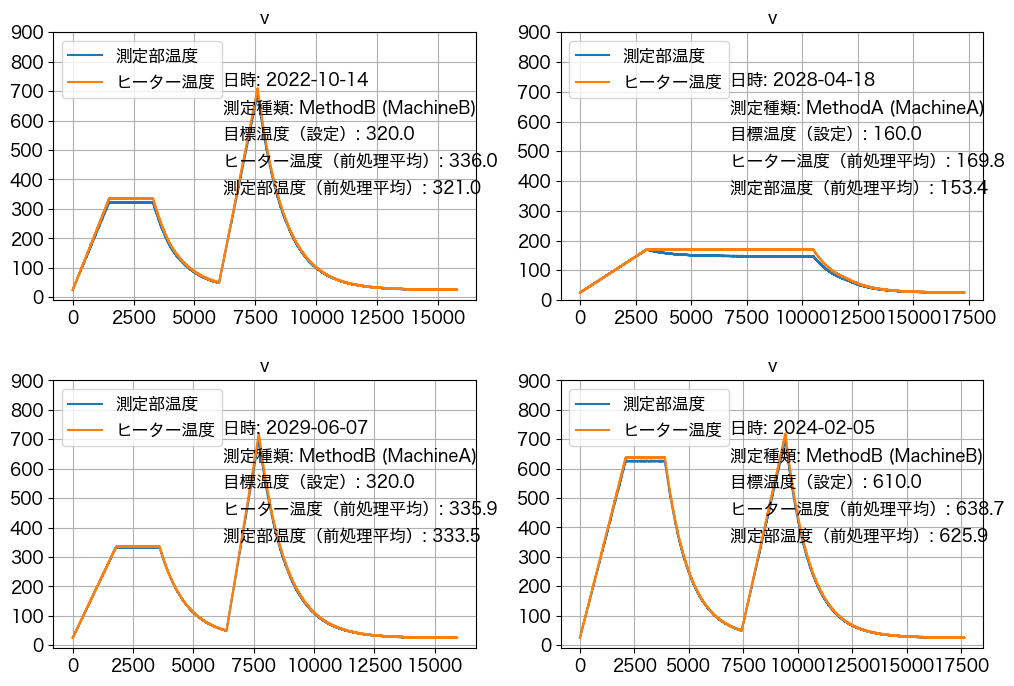

In [54]:
plt = plot_random_temperature_trends(summary_df, n_samples=4)

if IS_SAVEGRAPH:
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    savedir = os.path.join(OUTPUT_ROOT, "Graph/temp_trend")
    os.makedirs(savedir, exist_ok=True)
    graph_save_path = os.path.join(savedir, f'temperature_trend_random_created{current_time}.png',)
    plt.savefig(graph_save_path, bbox_inches="tight")
else:
    plt.show()

#### ヒーター温度 - 前処理目標温度 25~50℃

#### MachineB: before 2025 vs after 2025

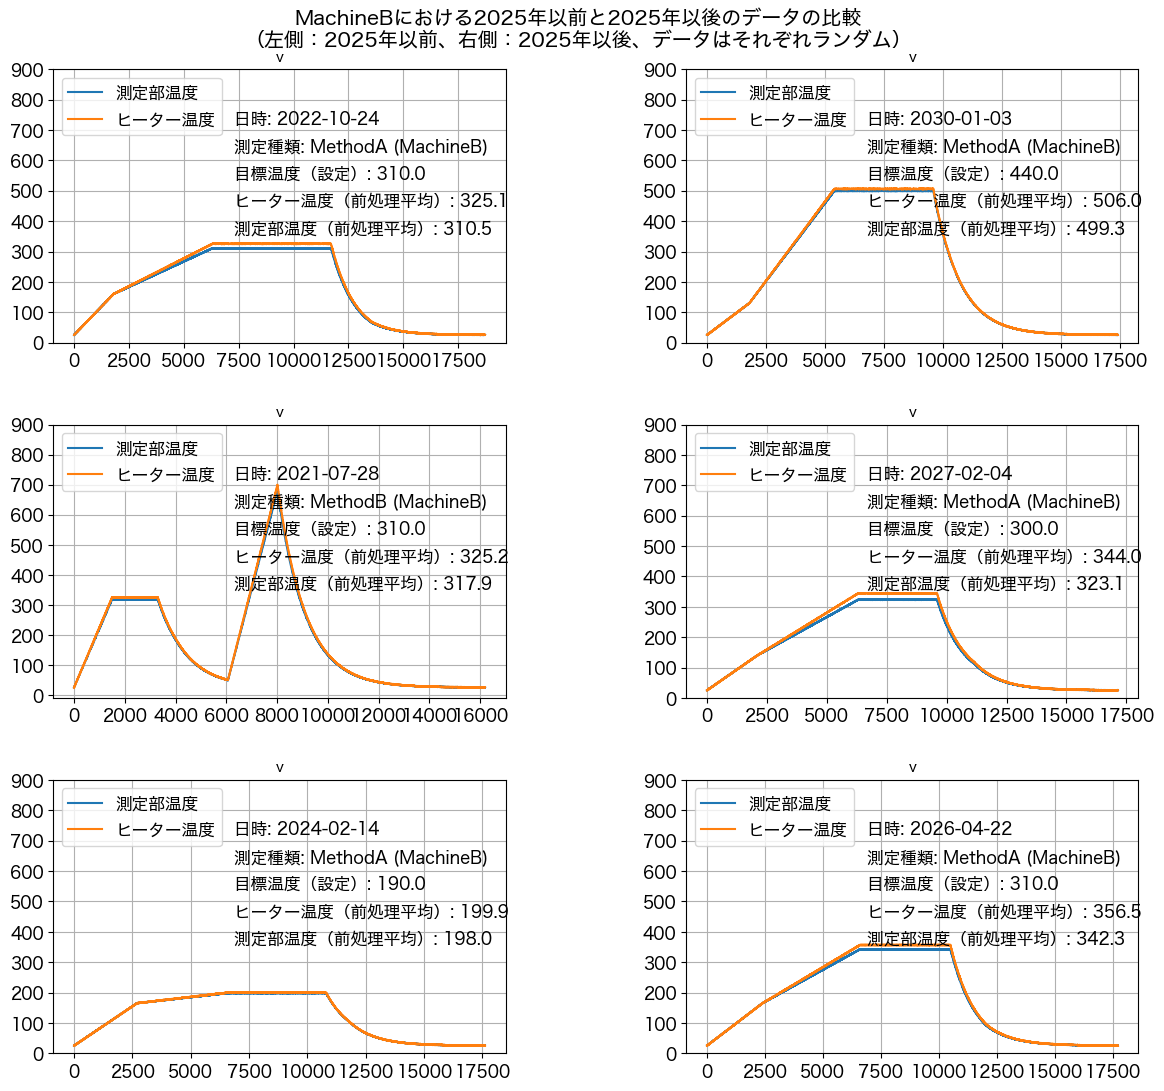

In [55]:
# First filter the dataframe
filtered_summary_df_machineB_before2025 = summary_df[(summary_df['machine'] == 'MachineB') & (summary_df['pretreatment_date'] < '2025-01-01')].copy()
filtered_summary_df_machineB_after2025 = summary_df[(summary_df['machine'] == 'MachineB') & (summary_df['pretreatment_date'] >= '2025-01-01')].copy()

plt = plot_paired_random_temperature_trends(
    filtered_summary_df_machineB_before2025, filtered_summary_df_machineB_after2025, n_samples=3,
    suptitle='MachineBにおける2025年以前と2025年以後のデータの比較\n（左側：2025年以前、右側：2025年以後、データはそれぞれランダム）'
)

if IS_SAVEGRAPH:
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    savedir = os.path.join(OUTPUT_ROOT, "Graph/temp_trend/MachineB_2025beforeafter")
    os.makedirs(savedir, exist_ok=True)
    graph_save_path = os.path.join(savedir, f'temperature_trend_MachineB_2025beforeafter_created{current_time}.png',)
    plt.savefig(graph_save_path, bbox_inches="tight")
else:
    plt.show()

### huge temperature difference data between sample tube inside and ヒーター温度

In [56]:
summary_df_hugetempdiff = summary_df[summary_df['heater_measured_diff'] > 100]
len(summary_df_hugetempdiff)

33

In [57]:
summary_df_hugetempdiff.head()

,trend_filepath,trend_filename,measurement_method,pretreatment_date,sample_filepath,operator,machine,internal_filepath,sample_name,sample_type,...,measured_value_a8_total_per_weight,measured_value_a8_total_0to15,measured_value_a8_total_0to15_per_weight,measured_value_a8_total_0to15_ratio,measured_temp,heater_temp,heater_measured_diff,heater_pretreatment_diff,measured_pretreatment_diff,period
20,Data/dummy_data/MachineB/UserK/MethodA/Trend_s...,Trend_sampleF_261116-MethodA-261202-1446.csv,MethodA,2026-12-02,Data/dummy_data/MachineB/UserK/MethodA/sampleF...,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleF_261116-...,sampleF_261116-MethodA-261202-1446,SampleF,...,3607.0326,3607.0326,3607.0326,1.0,216.371048,345.006656,128.635607,45.006656,-83.628952,After 2025-01-01
158,Data/dummy_data/MachineB/UserE/MethodA/Trend_s...,Trend_sampleA_301217-MethodA-310111-1157.csv,MethodA,2031-01-11,Data/dummy_data/MachineB/UserE/MethodA/sampleA...,UserE,MachineB,C:/MachineB/DATA/UserE/MethodA/sampleA_301217-...,sampleA_301217-MethodA-310111-1157,SampleA,...,2577.6668,2577.6668,2577.6668,1.0,201.469052,346.071547,144.602496,46.071547,-98.530948,After 2025-01-01
257,Data/dummy_data/MachineB/UserC/MethodA/Trend_s...,Trend_sampleC_280128-MethodA-280201-0816.csv,MethodA,2028-02-01,Data/dummy_data/MachineB/UserC/MethodA/sampleC...,UserC,MachineB,C:/MachineB/DATA/UserC/MethodA/sampleC_280128-...,sampleC_280128-MethodA-280201-0816,SampleC,...,2194.0099,2194.0099,2194.0099,1.0,261.201997,391.637271,130.435275,51.637271,-78.798003,After 2025-01-01
270,Data/dummy_data/MachineB/UserC/MethodA/Trend_s...,Trend_sampleB_300521-MethodA-300522-1440.csv,MethodA,2030-05-22,Data/dummy_data/MachineB/UserC/MethodA/sampleB...,UserC,MachineB,C:/MachineB/DATA/UserC/MethodA/sampleB_300521-...,sampleB_300521-MethodA-300522-1440,SampleB,...,2367.8268,2367.8268,2367.8268,1.0,317.856406,447.846922,129.990516,57.846922,-72.143594,After 2025-01-01
273,Data/dummy_data/MachineB/UserC/MethodA/Trend_s...,Trend_sampleD_200807-MethodA-200808-1700.csv,MethodA,2020-08-08,Data/dummy_data/MachineB/UserC/MethodA/sampleD...,UserC,MachineB,C:/MachineB/DATA/UserC/MethodA/sampleD_200807-...,sampleD_200807-MethodA-200808-1700,SampleD,...,2120.5526,2120.5526,2120.5526,1.0,160.093511,305.337770,145.244260,15.337770,-129.906489,Before 2025-01-01


In [58]:
row_idx = 0
if len(summary_df_hugetempdiff) > 0:
    display(summary_df_hugetempdiff.iloc[row_idx, :])
else:
    print("ヒーター温度 - 測定部温度が100℃を超えるデータはありません")

trend_filepath                              Data/dummy_data/MachineB/UserK/MethodA/Trend_s...
trend_filename                                   Trend_sampleF_261116-MethodA-261202-1446.csv
measurement_method                                                                    MethodA
pretreatment_date                                                         2026-12-02 00:00:00
sample_filepath                             Data/dummy_data/MachineB/UserK/MethodA/sampleF...
operator                                                                                UserK
machine                                                                              MachineB
internal_filepath                           C:/MachineB/DATA/UserK/MethodA/sampleF_261116-...
sample_name                                                sampleF_261116-MethodA-261202-1446
sample_type                                                                           SampleF
sample_weight                                               

Data/dummy_data/MachineB/UserK/MethodA/Trend_sampleF_261116-MethodA-261202-1446.csv


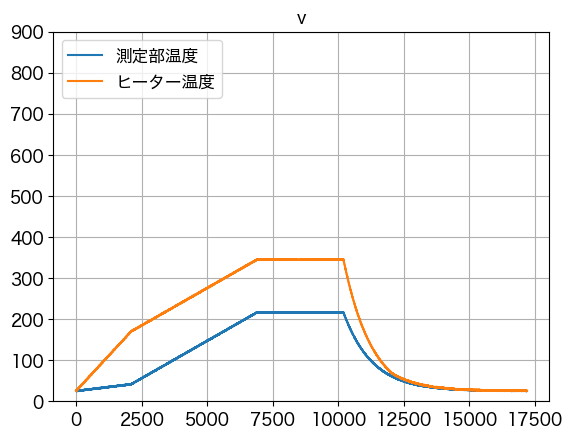

In [59]:
if len(summary_df_hugetempdiff) > 0:
    file_hugetempdiff = summary_df_hugetempdiff.iloc[row_idx, 0]
    print(file_hugetempdiff)
    fig, ax = plt.subplots()
    visualize_heater_and_measured_temp(file_hugetempdiff, ax)
else:
    print("ヒーター温度 - 測定部温度が100℃を超えるデータはありません")